In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import time as _time

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes


In [3]:
returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
features = np.load("../../data/features.npy")

# Comprobaciones básicas
print(returns.shape)   # (T, N)
print(features.shape)  # (N, T, P)


(1147, 169)
(169, 1147, 6)


In [4]:


prices = pd.read_parquet("../../data/prices.parquet")
volumes = pd.read_parquet("../../data/volumes.parquet")

print("prices range:", prices.index.min(), prices.index.max(), "shape:", prices.shape)
print("volumes range:", volumes.index.min(), volumes.index.max(), "shape:", volumes.shape)

prices range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)
volumes range: 2005-01-03 00:00:00 2024-12-31 00:00:00 shape: (6202, 169)


In [5]:
# Guardar el orden original de columnas para mapear features → returns
original_columns = returns.columns.tolist()

returns = returns.apply(pd.to_numeric, errors="coerce")
returns = returns.dropna(axis=0, how="any")
returns = returns.dropna(axis=1, how="all")

# Eliminar activos casi constantes (evitar NaN/correlaciones inestables)
std = returns.std(axis=0)
returns = returns.loc[:, std > 1e-8]
print("returns shape tras limpieza:", returns.shape)
if returns.shape[1] < 2:
    raise ValueError("No hay suficientes activos tras limpiar returns. Revisar la generación de returns.csv.")

# Sincronizar features con las columnas supervivientes en returns
surviving_idx = [original_columns.index(c) for c in returns.columns]
features = features[surviving_idx]
print("features shape tras sincronización:", features.shape)

R = returns.values
corr = np.corrcoef(R, rowvar=False)
print(f"Corr shape: {corr.shape} | rango: [{corr[np.triu_indices_from(corr,1)].min():.3f}, {corr[np.triu_indices_from(corr,1)].max():.3f}]")


returns shape tras limpieza: (1147, 169)
features shape tras sincronización: (169, 1147, 6)
Corr shape: (169, 169) | rango: [-0.185, 1.000]


In [6]:
def frobenius_distance(rho1, rho2, scale=1.5):
    """
    Calcula la distancia de Frobenius escalada entre dos matrices de densidad.
    Coincide con el repositorio del paper: scale=1.5 (por defecto).
    """
    diff = rho1 - rho2
    return scale * (0.5 * np.sqrt(np.trace(diff.conj().T @ diff)))

def compute_distance_matrix_paper(rho_list):
    """
    Calcula una matriz de distancias a partir de una lista de matrices de densidad
    usando la frobenius_distance del paper (scale=1.5).
    """
    N = len(rho_list)
    D = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            d = frobenius_distance(rho_list[i], rho_list[j])
            D[i, j] = d
            D[j, i] = d
    return D


In [7]:
def quasi_diagonal(linkage_matrix):
    """
    Cuasi-diagonalización de la matriz de enlace (igual que en el repositorio del paper).
    Devuelve una lista ordenada de los índices originales.
    """
    linkage_matrix = linkage_matrix.astype(int)
    sorted_items = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
    num_items = linkage_matrix[-1, 3]

    while sorted_items.max() >= num_items:
        sorted_items.index = range(0, sorted_items.shape[0] * 2, 2)
        dataframe = sorted_items[sorted_items >= num_items]
        i = dataframe.index
        j = dataframe.values - num_items
        sorted_items[i] = linkage_matrix[j, 0]
        dataframe = pd.Series(linkage_matrix[j, 1], index=i + 1)
        sorted_items = sorted_items._append(dataframe)
        sorted_items = sorted_items.sort_index()
        sorted_items.index = range(sorted_items.shape[0])
    return sorted_items.tolist()

# Ordenación HRP clásica: correlación → distancia → enlace simple → quasi_diagonal
dist_classical = np.sqrt((1 - corr) / 2.0)
dist_classical = 0.5 * (dist_classical + dist_classical.T)
np.fill_diagonal(dist_classical, 0.0)
dist_classical = np.nan_to_num(dist_classical)

link_classical = linkage(squareform(dist_classical), method="single")
order_classical = quasi_diagonal(link_classical)
order_classical = [int(x) for x in order_classical]

corr_classical = corr[np.ix_(order_classical, order_classical)]


In [8]:
alpha = 2.0

# Ventana temporal (~3 años de días de negociación)
T_window = 756
window = slice(-T_window, None)

# P=6 features definidas en compute_financial_features(window=5) del paper:
# f1=retorno, f2=media móvil, f3=desv. estándar móvil, f4=retorno acumulado, f5=asimetría, f6=curtosis
N = returns.shape[1]
T_total = returns.shape[0]
P = 6
features_p6 = np.zeros((N, T_total, P))
from scipy import stats as sp_stats
for j in range(N):
    s = R[:, j]
    for t in range(T_total):
        st = max(0, t - 4)
        w = s[st:t+1]
        features_p6[j, t, 0] = s[t]                                            # retorno diario
        features_p6[j, t, 1] = np.mean(w)                                      # media móvil
        features_p6[j, t, 2] = np.std(w, ddof=1) if len(w) > 1 else 0.0       # desv. estándar móvil
        features_p6[j, t, 3] = np.prod(1 + w) - 1                              # retorno acumulado
        features_p6[j, t, 4] = sp_stats.skew(w) if len(w) > 2 else 0.0        # asimetría
        features_p6[j, t, 5] = sp_stats.kurtosis(w) if len(w) > 3 else 0.0    # curtosis

rho_list = []
for i in range(N):
    rho_i = average_density_matrix(
        features_p6[i][window],  # (T_window, 6)
        alpha
    )
    rho_list.append(rho_i)

# Usar la distancia del paper (scale=1.5)
D_quantum = compute_distance_matrix_paper(rho_list)
print(f"D_quantum rango: [{D_quantum.min():.4f}, {D_quantum.max():.4f}]")


D_quantum rango: [0.0000, 0.3455]


In [9]:
def quantum_ordering_ward(D):
    """
    Ordenación QHRP usando enlace de Ward,
    reproduciendo la función quantum_ordering del paper.
    """
    condensed_D = squareform(D)
    Z = linkage(condensed_D, method="ward")
    order = leaves_list(Z)
    return order


In [10]:
# Ordenación cuántica con enlace de Ward (método del paper)
order_quantum = quantum_ordering_ward(D_quantum)
D_quantum_ordered = D_quantum[np.ix_(order_quantum, order_quantum)]

corr_quantum = corr[np.ix_(order_quantum, order_quantum)]


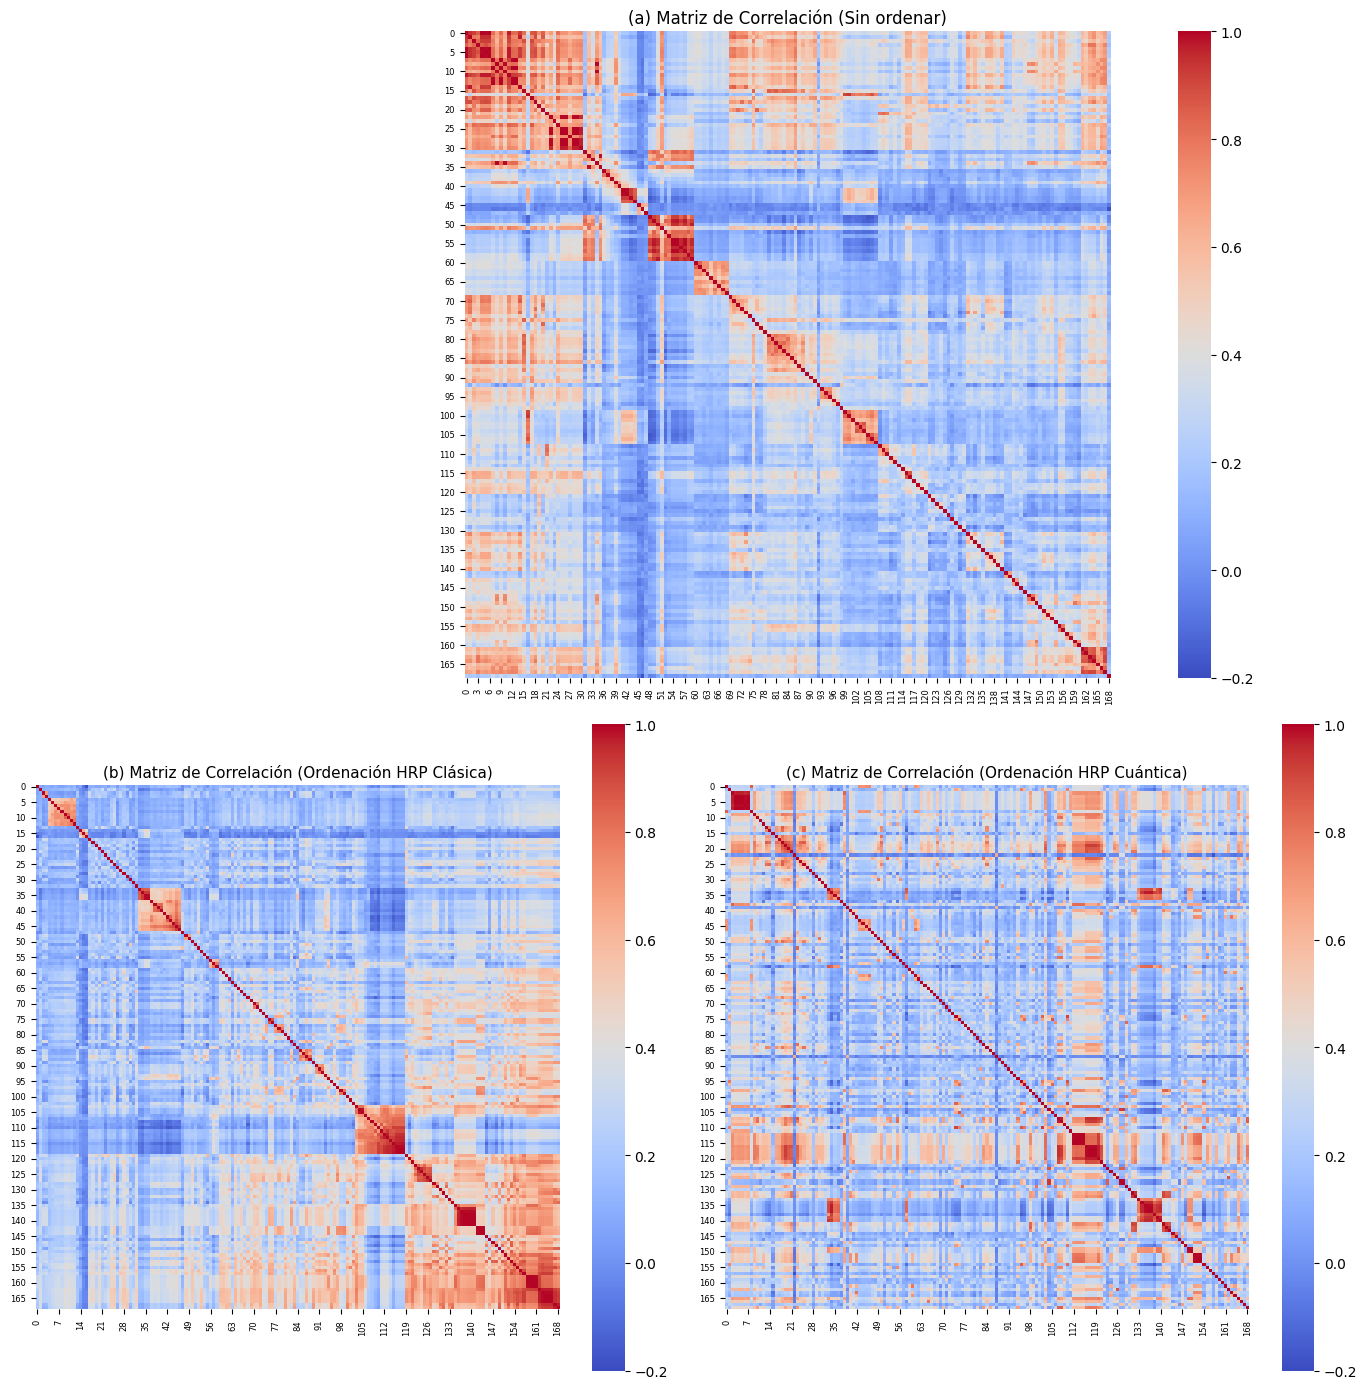

In [11]:
out_dir = os.path.abspath("../../latex/img")
os.makedirs(out_dir, exist_ok=True)

fig = plt.figure(figsize=(14, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Sin ordenar ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Matriz de Correlación (Sin ordenar)", fontsize=12)
ax0.tick_params(labelsize=6)

# ---------- (b) HRP Clásico ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Matriz de Correlación (Ordenación HRP Clásica)", fontsize=11)
ax1.tick_params(labelsize=6)

# ---------- (c) HRP Cuántico ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Matriz de Correlación (Ordenación HRP Cuántica)", fontsize=11)
ax2.tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.pdf"), bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-corr-matrices.jpg"), dpi=300, bbox_inches="tight")
plt.show()


## Características antiguas de "transformación matemática" (código muerto en el repositorio)

La función `fetch_stock_data` del repositorio del autor tiene **dos** bloques de características — el primero usa transformaciones matemáticas de un solo retorno (sin ventana móvil), y el segundo (actualmente activo) lo sobrescribe con `compute_financial_features` (ventana móvil). Las mismas características antiguas aparecen comentadas en `simulate_asset_features_regimes`.

**Características antiguas** (puntuales, sin ventana móvil):
| # | Característica | Fórmula |
|---|---|---|
| f0 | retorno | r |
| f1 | retorno al cuadrado | r² |
| f2 | transformación potencial | \|r\|^1.5 |
| f3 | logaritmo con signo | sign(r) · log(1+\|r\|) |
| f4 | tanh | tanh(r) |
| f5 | raíz cuadrada con signo | sign(r) · √(\|r\|) |

A continuación probamos si la Figura 4 del paper se generó con estas características antiguas.

In [12]:
# ── Features antiguas de "transformación matemática" (código muerto del repositorio del autor) ──
# Son transformaciones por valor de retorno (SIN ventana móvil):
#   f0 = r,  f1 = r²,  f2 = |r|^1.5,  f3 = sign(r)·log(1+|r|),
#   f4 = tanh(r),  f5 = sign(r)·√(|r|+1e-6)

features_old = np.zeros((N, T_total, 6))
for j in range(N):
    for t in range(T_total):
        r = R[t, j]
        features_old[j, t, 0] = r                                              # retorno bruto (señal lineal)
        features_old[j, t, 1] = r ** 2                                         # retorno al cuadrado (proxy de volatilidad)
        features_old[j, t, 2] = abs(r) ** 1.5                                  # transformación potencial (enfatiza movimientos grandes)
        features_old[j, t, 3] = np.log1p(abs(r)) * np.sign(r)                  # logaritmo con signo (comprime colas, mantiene signo)
        features_old[j, t, 4] = np.tanh(r)                                     # tanh (acotada ≈ recorte suave a [-1,1])
        features_old[j, t, 5] = np.sign(r) * np.sqrt(abs(r) + 1e-6)           # raíz con signo (amplifica movimientos pequeños)

# Calcular matriz de distancias para cada P con features ANTIGUAS
D_old_per_p = {}
for p in range(1, 7):
    t0 = _time.time()
    feats = features_old[:, :, :p]

    rho_list_old = []
    for i in range(N):
        rho_i = average_density_matrix(feats[i][window], alpha)
        rho_list_old.append(rho_i)

    D_old = compute_distance_matrix_paper(rho_list_old)
    D_old_per_p[p] = D_old

    off = D_old[np.triu_indices_from(D_old, 1)]
    elapsed = _time.time() - t0
    print(f"ANTIGUAS P={p}  rango: [{off.min():.4f}, {off.max():.4f}]  "
          f"densidad: {rho_list_old[0].shape}  tiempo: {elapsed:.1f}s")

# Calcular matriz de distancias para cada P con features NUEVAS (compute_financial_features)
print("\n--- Features NUEVAS (ventana móvil) ---")
D_per_p = {}
for p in range(1, 7):
    t0 = _time.time()
    feats = features_p6[:, :, :p]

    rho_list_new = []
    for i in range(N):
        rho_i = average_density_matrix(feats[i][window], alpha)
        rho_list_new.append(rho_i)

    D_new = compute_distance_matrix_paper(rho_list_new)
    D_per_p[p] = D_new

    off = D_new[np.triu_indices_from(D_new, 1)]
    elapsed = _time.time() - t0
    print(f"NUEVAS P={p}  rango: [{off.min():.4f}, {off.max():.4f}]  "
          f"densidad: {rho_list_new[0].shape}  tiempo: {elapsed:.1f}s")


ANTIGUAS P=1  rango: [0.0016, 0.9110]  densidad: (2, 2)  tiempo: 97.3s
ANTIGUAS P=2  rango: [0.0027, 0.9214]  densidad: (4, 4)  tiempo: 175.0s
ANTIGUAS P=3  rango: [0.0033, 1.0154]  densidad: (8, 8)  tiempo: 250.3s
ANTIGUAS P=4  rango: [0.0041, 0.9518]  densidad: (16, 16)  tiempo: 326.3s
ANTIGUAS P=5  rango: [0.0048, 0.9475]  densidad: (32, 32)  tiempo: 422.9s
ANTIGUAS P=6  rango: [0.0050, 0.8474]  densidad: (64, 64)  tiempo: 502.3s

--- Features NUEVAS (ventana móvil) ---
NUEVAS P=1  rango: [0.0016, 0.9110]  densidad: (2, 2)  tiempo: 95.3s
NUEVAS P=2  rango: [0.0036, 0.8493]  densidad: (4, 4)  tiempo: 175.3s
NUEVAS P=3  rango: [0.0059, 0.8313]  densidad: (8, 8)  tiempo: 251.9s
NUEVAS P=4  rango: [0.0074, 0.7968]  densidad: (16, 16)  tiempo: 333.4s
NUEVAS P=5  rango: [0.0074, 0.5188]  densidad: (32, 32)  tiempo: 423.1s
NUEVAS P=6  rango: [0.0094, 0.3455]  densidad: (64, 64)  tiempo: 502.7s


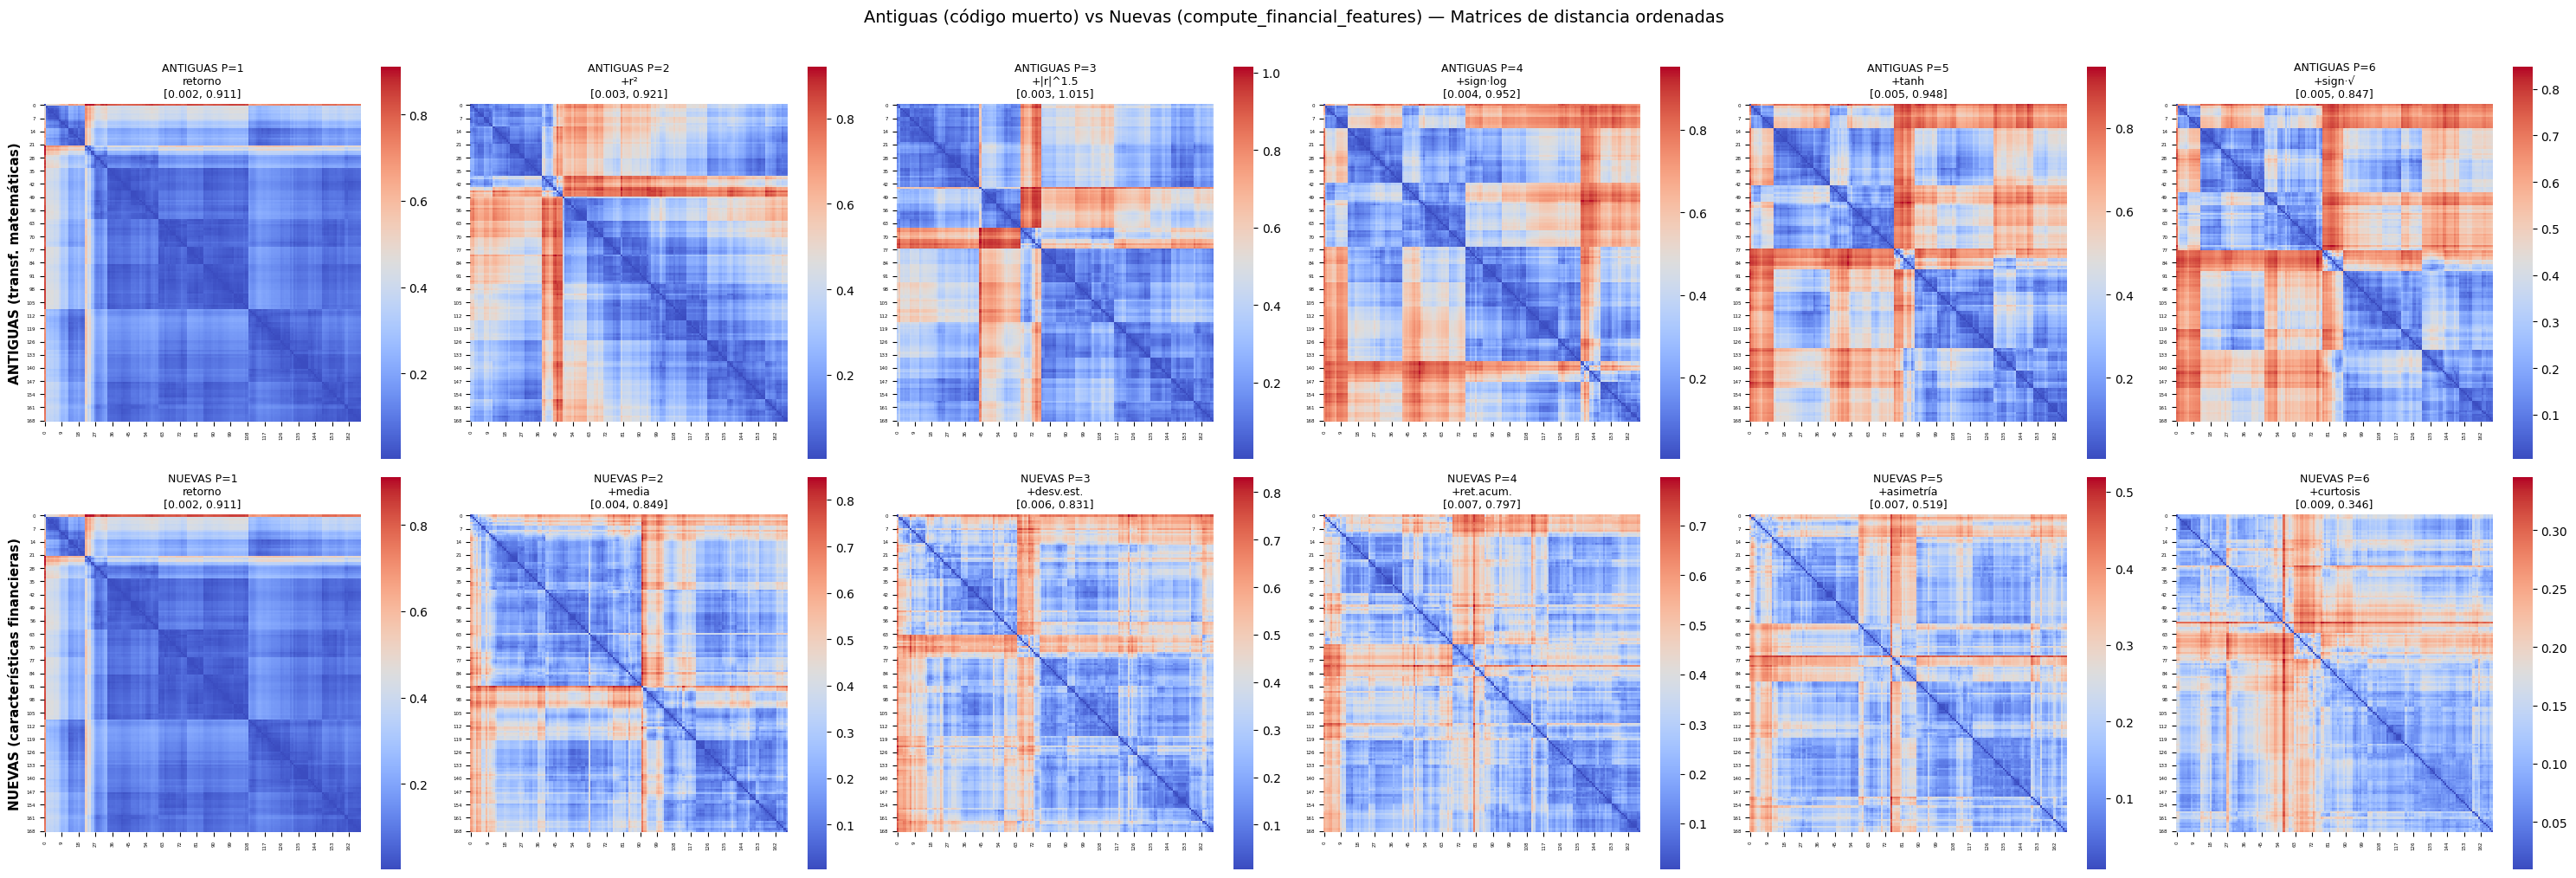

In [13]:
# ── Comparación lado a lado: features ANTIGUAS vs NUEVAS para cada P ──────
fig, axes = plt.subplots(2, 6, figsize=(30, 10))

feature_labels_new = ["retorno", "+media", "+desv.est.", "+ret.acum.", "+asimetría", "+curtosis"]
feature_labels_old = ["retorno", "+r²", "+|r|^1.5", "+sign·log", "+tanh", "+sign·√"]

for col, p in enumerate(range(1, 7)):
    # Features ANTIGUAS
    D_old = D_old_per_p[p]
    order_old = quantum_ordering_ward(D_old)
    D_old_ord = D_old[np.ix_(order_old, order_old)]
    off_old = D_old[np.triu_indices_from(D_old, 1)]

    sns.heatmap(
        D_old_ord, cmap="coolwarm",
        vmin=off_old.min(), vmax=off_old.max(),
        square=True, cbar=True, ax=axes[0, col],
    )
    axes[0, col].set_title(
        f"ANTIGUAS P={p}\n{feature_labels_old[col]}\n[{off_old.min():.3f}, {off_old.max():.3f}]",
        fontsize=9
    )
    axes[0, col].tick_params(labelsize=4)

    # Features NUEVAS (compute_financial_features)
    D_new = D_per_p[p]
    order_new = quantum_ordering_ward(D_new)
    D_new_ord = D_new[np.ix_(order_new, order_new)]
    off_new = D_new[np.triu_indices_from(D_new, 1)]

    sns.heatmap(
        D_new_ord, cmap="coolwarm",
        vmin=off_new.min(), vmax=off_new.max(),
        square=True, cbar=True, ax=axes[1, col],
    )
    axes[1, col].set_title(
        f"NUEVAS P={p}\n{feature_labels_new[col]}\n[{off_new.min():.3f}, {off_new.max():.3f}]",
        fontsize=9
    )
    axes[1, col].tick_params(labelsize=4)

axes[0, 0].set_ylabel("ANTIGUAS (transf. matemáticas)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("NUEVAS (características financieras)", fontsize=11, fontweight="bold")

plt.suptitle(
    "Antiguas (código muerto) vs Nuevas (compute_financial_features) — Matrices de distancia ordenadas",
    fontsize=14, y=1.01
)
plt.tight_layout()
fig.savefig(
    os.path.join(out_dir, "fig4-old-vs-new-features.png"),
    dpi=300, bbox_inches="tight"
)
plt.show()

ANTIGUAS P=6, con ventana, scale=1.0: [0.0033, 0.5649]
Usando vmax = 0.55


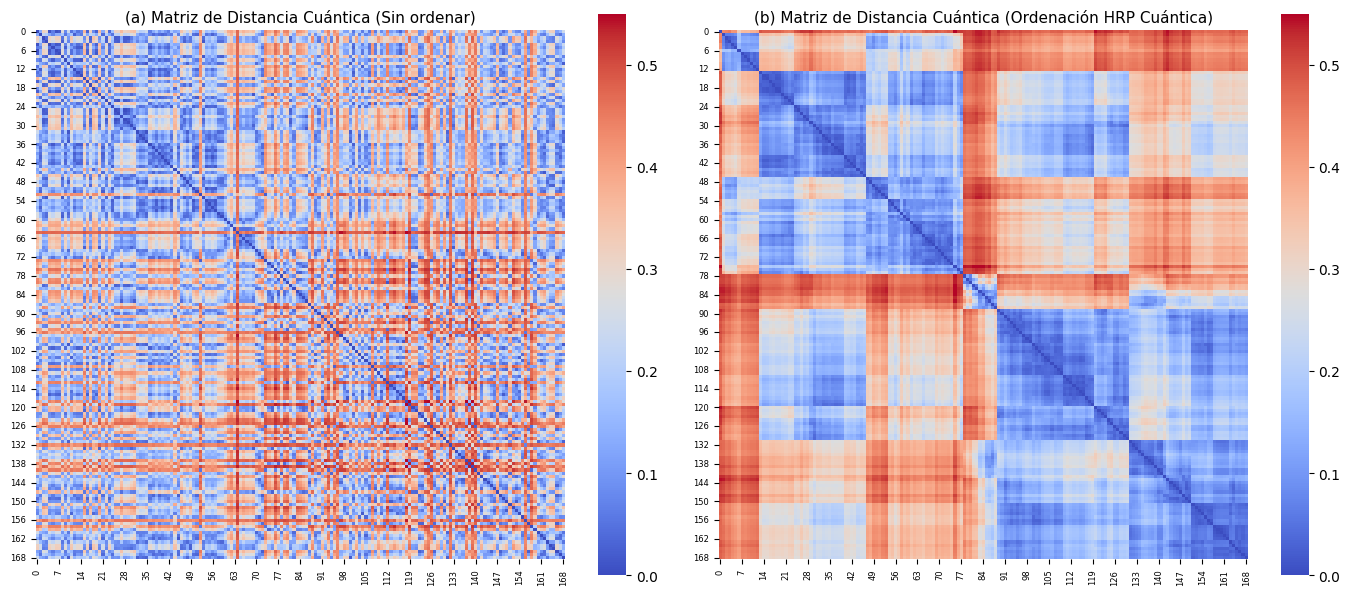

In [14]:
# ── HALLAZGO CLAVE: la fórmula de la tesis dice scale=1.0, NO 1.5 ─────────
# d_F(ρ_i, ρ_j) = ½ √Tr[(ρ_i - ρ_j)²]  (sin factor de escala)
# El código usa scale=1.5, pero la fórmula del paper tiene scale=1.0.
# Reescalando nuestras distancias existentes: D_scale1 = D_scale1.5 / 1.5

# Features ANTIGUAS P=6, con ventana, SCALE=1.0 (coincide con la fórmula de la tesis)
D_best = D_old_per_p[6] / 1.5   # convertir de scale=1.5 a scale=1.0
off_best = D_best[np.triu_indices_from(D_best, 1)]
print(f"ANTIGUAS P=6, con ventana, scale=1.0: [{off_best.min():.4f}, {off_best.max():.4f}]")

order_best = quantum_ordering_ward(D_best)
D_best_ordered = D_best[np.ix_(order_best, order_best)]

# Usar vmax ligeramente por debajo del máximo para que más valores saturen a rojo
# La barra de color del paper recorta visualmente algunos valores → bloques rojos más vívidos
vmax_fig = 0.55
print(f"Usando vmax = {vmax_fig}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(D_best, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0])
axes[0].set_title("(a) Matriz de Distancia Cuántica (Sin ordenar)", fontsize=11)
axes[0].tick_params(labelsize=6)

sns.heatmap(D_best_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1])
axes[1].set_title("(b) Matriz de Distancia Cuántica (Ordenación HRP Cuántica)", fontsize=11)
axes[1].tick_params(labelsize=6)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-best-match.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-best-match.pdf"), bbox_inches="tight")
plt.show()


## Test de permutación: mismos datos, orden de activos aleatorio

Permutamos el orden de las columnas de los activos y recalculamos todo desde cero.
Los paneles **sin ordenar** deberían verse diferentes (píxeles reordenados), mientras que
los paneles **ordenados** (HRP clásico, HRP cuántico) deberían ser idénticos — demostrando
que el clustering es invariante a permutaciones.

In [15]:
# ── Crear una permutación aleatoria de los índices de activos ──────────────
rng = np.random.default_rng(42)
perm = rng.permutation(N)
print(f"Primeros 10 índices de la permutación: {perm[:10]}")

# Reordenar columnas de returns y features según la permutación
returns_shuf = returns.iloc[:, perm]
R_shuf = returns_shuf.values
features_old_shuf = features_old[perm]
features_p6_shuf = features_p6[perm]

# Recalcular correlación con los returns permutados
corr_shuf = np.corrcoef(R_shuf, rowvar=False)
print(f"corr_shuf shape: {corr_shuf.shape}")


Primeros 10 índices de la permutación: [152  54   7  33 125  24  56  93 120 108]
corr_shuf shape: (169, 169)


In [16]:
# ── Ordenación HRP clásica sobre datos permutados ─────────────────────────
dist_classical_shuf = np.sqrt((1 - corr_shuf) / 2.0)
dist_classical_shuf = 0.5 * (dist_classical_shuf + dist_classical_shuf.T)
np.fill_diagonal(dist_classical_shuf, 0.0)
dist_classical_shuf = np.nan_to_num(dist_classical_shuf)

link_classical_shuf = linkage(squareform(dist_classical_shuf), method="single")
order_classical_shuf = quasi_diagonal(link_classical_shuf)
order_classical_shuf = [int(x) for x in order_classical_shuf]

corr_classical_shuf = corr_shuf[np.ix_(order_classical_shuf, order_classical_shuf)]
print("Ordenación HRP clásica (permutada) calculada.")


Ordenación HRP clásica (permutada) calculada.


In [17]:
# ── Ordenación cuántica sobre datos permutados (features ANTIGUAS P=6, scale=1.0) ──
rho_list_shuf = []
for i in range(N):
    rho_i = average_density_matrix(features_old_shuf[i][window], alpha)
    rho_list_shuf.append(rho_i)

D_quantum_shuf = compute_distance_matrix_paper(rho_list_shuf) / 1.5  # scale=1.0
order_quantum_shuf = quantum_ordering_ward(D_quantum_shuf)
D_quantum_shuf_ordered = D_quantum_shuf[np.ix_(order_quantum_shuf, order_quantum_shuf)]
corr_quantum_shuf = corr_shuf[np.ix_(order_quantum_shuf, order_quantum_shuf)]

print(f"D_quantum_shuf rango: [{D_quantum_shuf.min():.4f}, {D_quantum_shuf.max():.4f}]")
print("Ordenación cuántica (permutada) calculada.")


D_quantum_shuf rango: [0.0000, 0.5649]
Ordenación cuántica (permutada) calculada.


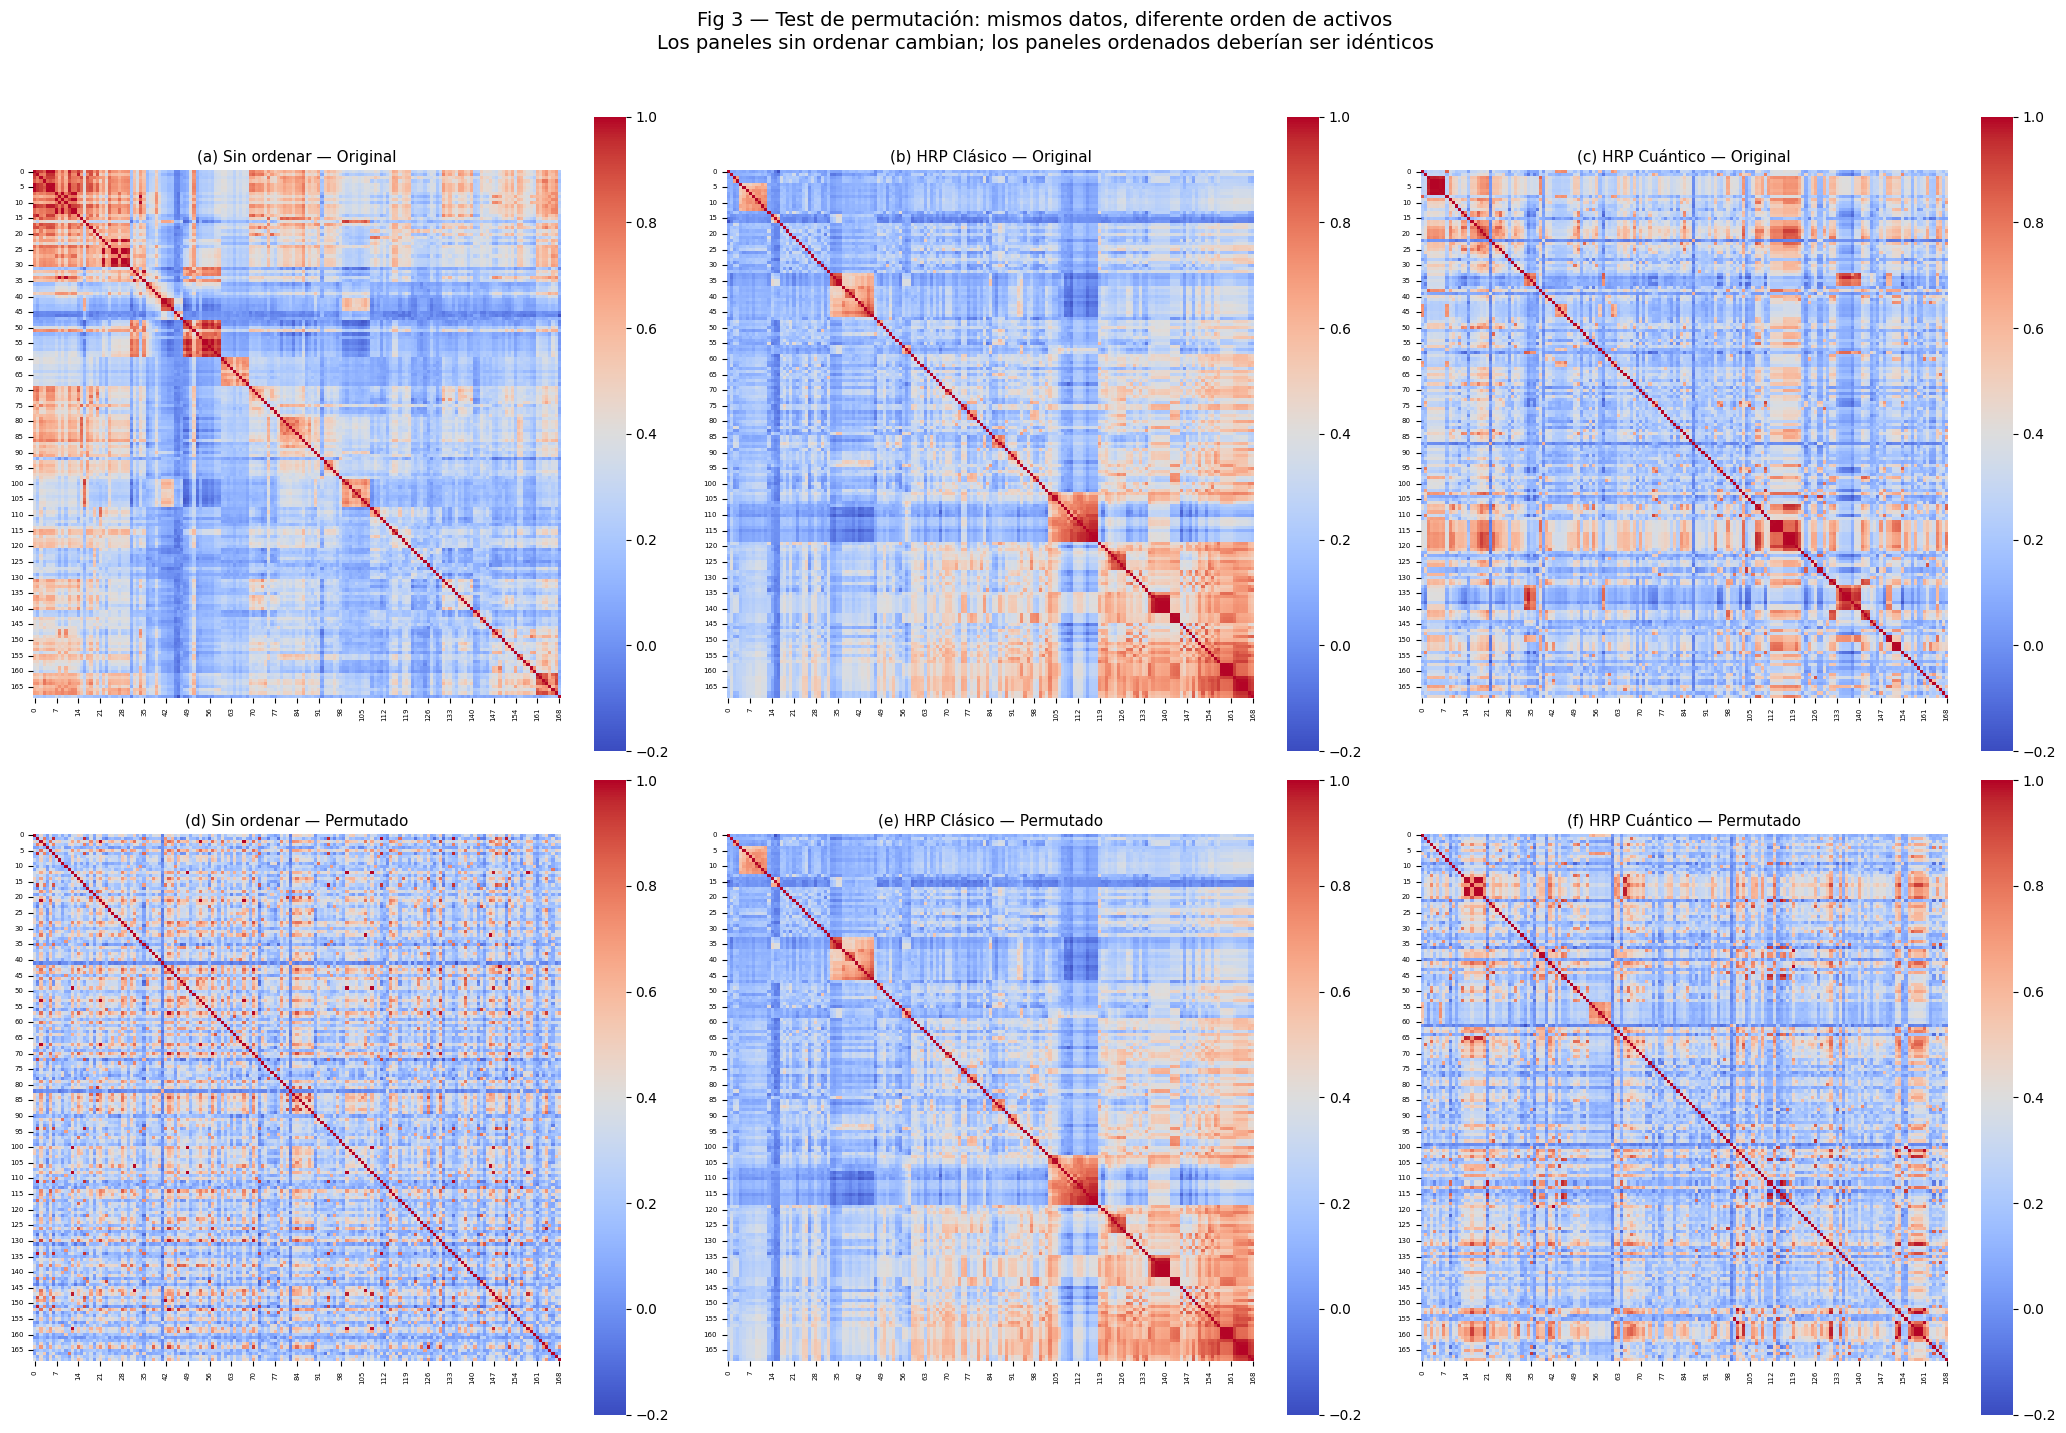

In [18]:
# ── Comparación Fig 3: orden original vs orden permutado ──────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 14))

titles_top = [
    "(a) Sin ordenar — Original",
    "(b) HRP Clásico — Original",
    "(c) HRP Cuántico — Original",
]
titles_bot = [
    "(d) Sin ordenar — Permutado",
    "(e) HRP Clásico — Permutado",
    "(f) HRP Cuántico — Permutado",
]
mats_top = [corr, corr_classical, corr_quantum]
mats_bot = [corr_shuf, corr_classical_shuf, corr_quantum_shuf]

for col in range(3):
    for row, (mats, titles) in enumerate([(mats_top, titles_top), (mats_bot, titles_bot)]):
        sns.heatmap(
            mats[col], cmap="coolwarm", vmin=-0.2, vmax=1.0,
            square=True, cbar=True, ax=axes[row, col],
        )
        axes[row, col].set_title(titles[col], fontsize=11)
        axes[row, col].tick_params(labelsize=5)

plt.suptitle(
    "Fig 3 — Test de permutación: mismos datos, diferente orden de activos\n"
    "Los paneles sin ordenar cambian; los paneles ordenados deberían ser idénticos",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


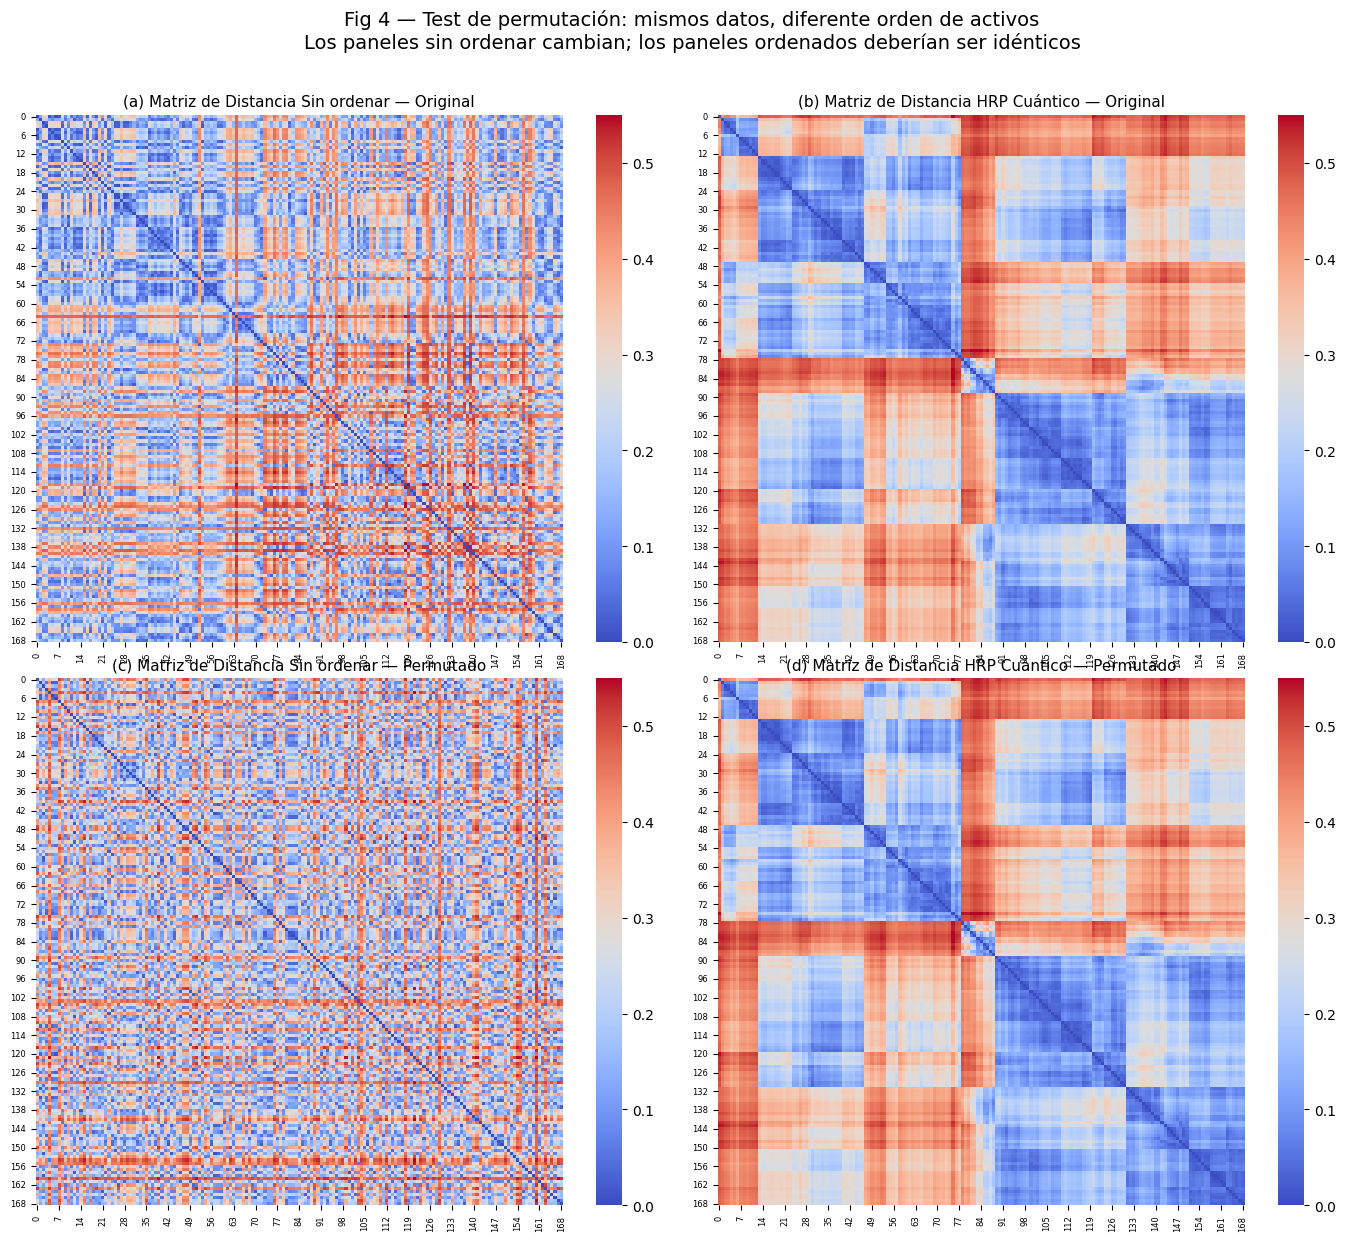

In [19]:
# ── Comparación Fig 4: orden original vs orden permutado ──────────────────
vmax_fig = 0.55

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Fila superior: original
sns.heatmap(D_best, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0, 0])
axes[0, 0].set_title("(a) Matriz de Distancia Sin ordenar — Original", fontsize=11)
axes[0, 0].tick_params(labelsize=6)

D_best_ordered_orig = D_best[np.ix_(order_best, order_best)]
sns.heatmap(D_best_ordered_orig, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0, 1])
axes[0, 1].set_title("(b) Matriz de Distancia HRP Cuántico — Original", fontsize=11)
axes[0, 1].tick_params(labelsize=6)

# Fila inferior: permutado
sns.heatmap(D_quantum_shuf, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1, 0])
axes[1, 0].set_title("(c) Matriz de Distancia Sin ordenar — Permutado", fontsize=11)
axes[1, 0].tick_params(labelsize=6)

sns.heatmap(D_quantum_shuf_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1, 1])
axes[1, 1].set_title("(d) Matriz de Distancia HRP Cuántico — Permutado", fontsize=11)
axes[1, 1].tick_params(labelsize=6)

plt.suptitle(
    "Fig 4 — Test de permutación: mismos datos, diferente orden de activos\n"
    "Los paneles sin ordenar cambian; los paneles ordenados deberían ser idénticos",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()


In [20]:
# ── Utilidades para identificar exactamente cada celda de las matrices ───────
def apply_sparse_ticker_ticks(ax, tickers, max_labels=28):
    n = len(tickers)
    if n == 0:
        ax.set_xticks([])
        ax.set_yticks([])
        return

    max_labels = max(1, int(max_labels))
    step = max(1, int(np.ceil(n / max_labels)))
    idx = np.arange(0, n, step)
    labels = [f"{i}:{tickers[i]}" for i in idx]

    # En heatmap, el centro de celda i esta en i+0.5
    ax.set_xticks(idx + 0.5)
    ax.set_yticks(idx + 0.5)
    ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticklabels(labels, rotation=0, fontsize=6)
    ax.set_xlabel("Activo (indice:ticker)")
    ax.set_ylabel("Activo (indice:ticker)")


def save_index_map_csv(path, ordered_tickers, raw_permuted_index):
    pd.DataFrame(
        {
            "ordered_index": np.arange(len(ordered_tickers), dtype=int),
            "ticker": ordered_tickers,
            "raw_permuted_index": np.asarray(raw_permuted_index, dtype=int),
        }
    ).to_csv(path, index=False)


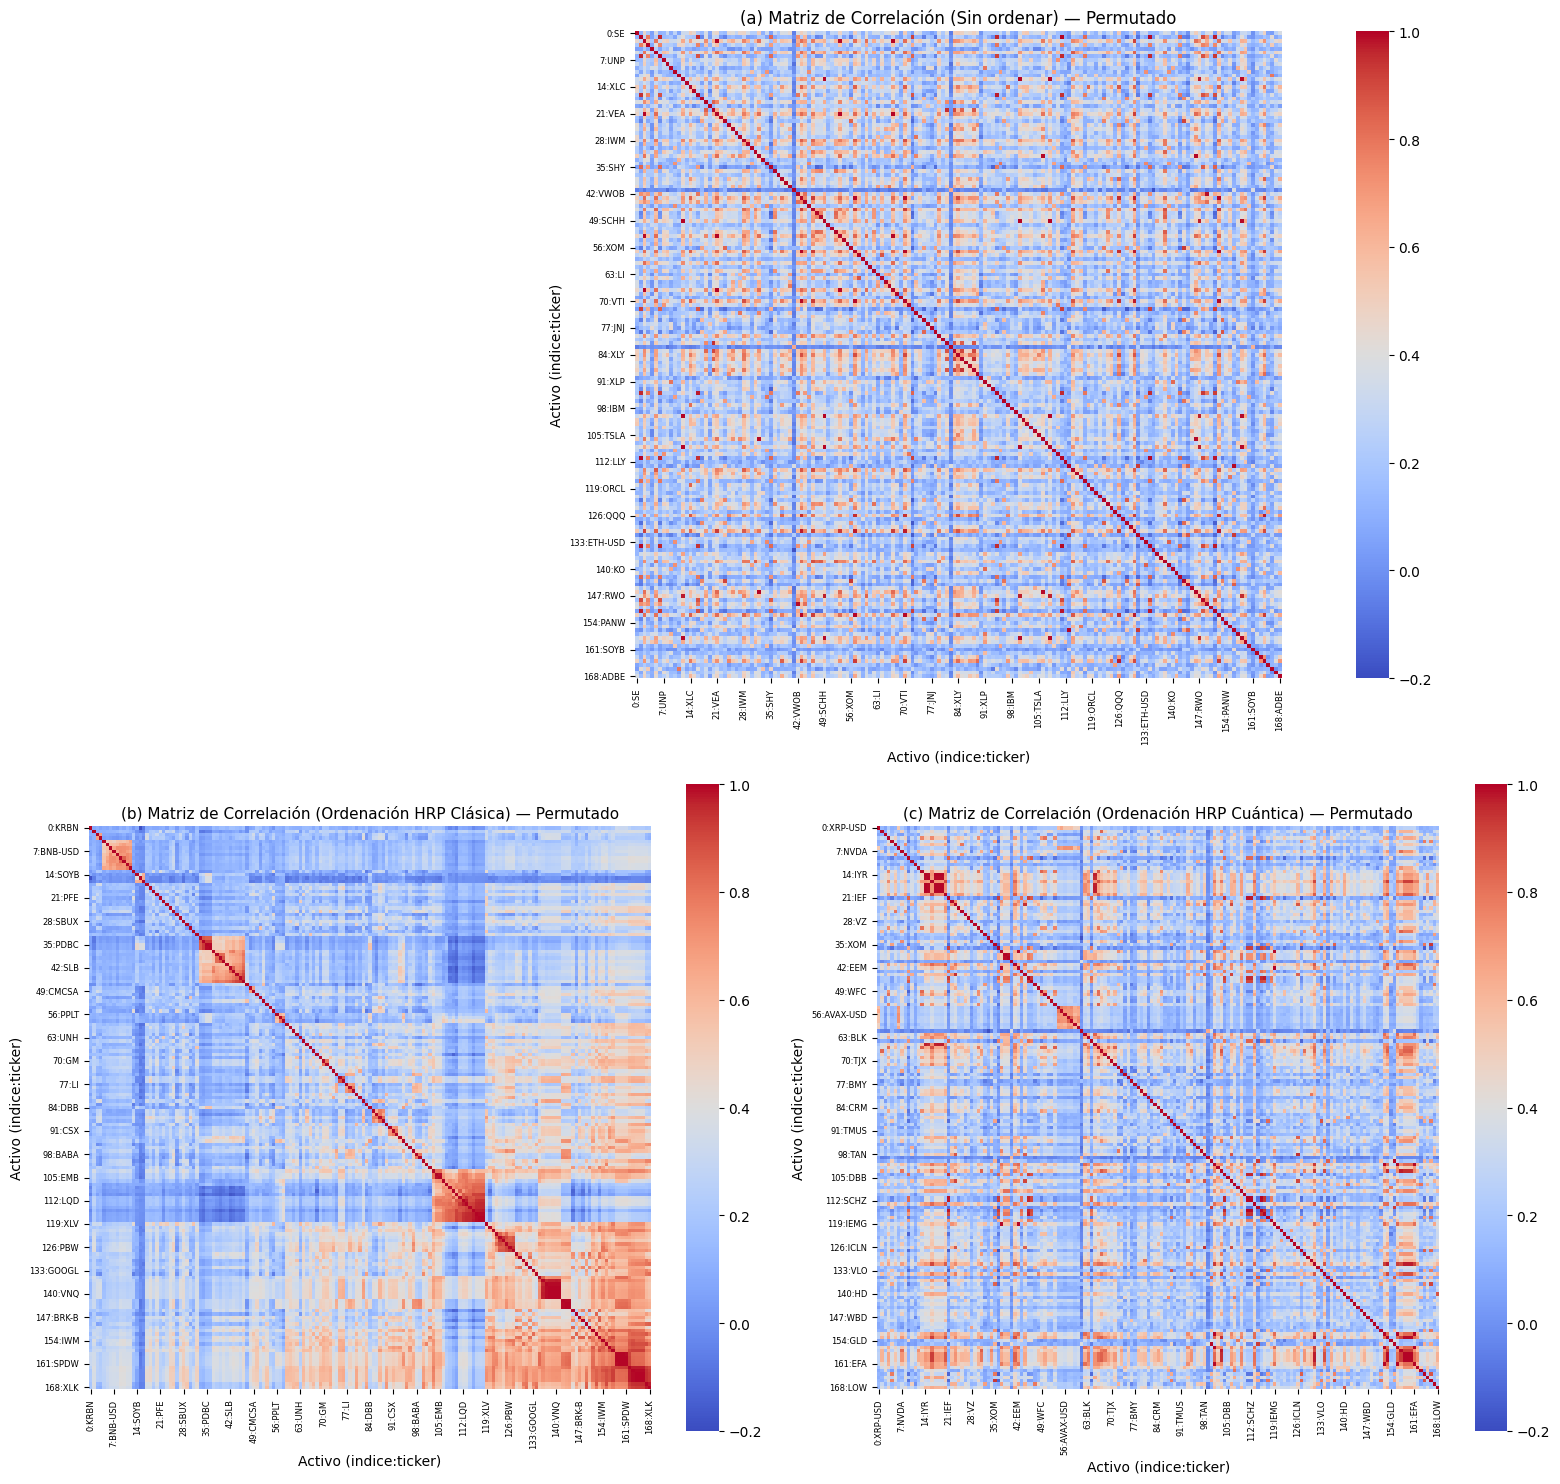

Mapas índice↔ticker guardados:
- /home/iker/TFG/latex/img/fig3-shuffled-index-map-raw.csv
- /home/iker/TFG/latex/img/fig3-shuffled-index-map-classical.csv
- /home/iker/TFG/latex/img/fig3-shuffled-index-map-quantum.csv


In [21]:
# ── Fig 3 — Permutado (independiente) ──────────────────────────────────────
tickers_raw_shuf = returns_shuf.columns.tolist()
tickers_classical_shuf = [tickers_raw_shuf[i] for i in order_classical_shuf]
tickers_quantum_shuf = [tickers_raw_shuf[i] for i in order_quantum_shuf]
max_labels = 28

fig = plt.figure(figsize=(16, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# ---------- (a) Sin ordenar — Permutado ----------
ax0 = fig.add_subplot(gs[0, :])
sns.heatmap(
    corr_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax0
)
ax0.set_title("(a) Matriz de Correlación (Sin ordenar) — Permutado", fontsize=12)
apply_sparse_ticker_ticks(ax0, tickers_raw_shuf, max_labels=max_labels)

# ---------- (b) HRP Clásico — Permutado ----------
ax1 = fig.add_subplot(gs[1, 0])
sns.heatmap(
    corr_classical_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax1
)
ax1.set_title("(b) Matriz de Correlación (Ordenación HRP Clásica) — Permutado", fontsize=11)
apply_sparse_ticker_ticks(ax1, tickers_classical_shuf, max_labels=max_labels)

# ---------- (c) HRP Cuántico — Permutado ----------
ax2 = fig.add_subplot(gs[1, 1])
sns.heatmap(
    corr_quantum_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=ax2
)
ax2.set_title("(c) Matriz de Correlación (Ordenación HRP Cuántica) — Permutado", fontsize=11)
apply_sparse_ticker_ticks(ax2, tickers_quantum_shuf, max_labels=max_labels)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-shuffled.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-shuffled.pdf"), bbox_inches="tight")
plt.show()

# Guardar trazabilidad índice↔ticker para identificar cualquier celda (i, j)
map_raw = os.path.join(out_dir, "fig3-shuffled-index-map-raw.csv")
map_classical = os.path.join(out_dir, "fig3-shuffled-index-map-classical.csv")
map_quantum = os.path.join(out_dir, "fig3-shuffled-index-map-quantum.csv")

save_index_map_csv(map_raw, tickers_raw_shuf, np.arange(N))
save_index_map_csv(map_classical, tickers_classical_shuf, order_classical_shuf)
save_index_map_csv(map_quantum, tickers_quantum_shuf, order_quantum_shuf)

print("Mapas índice↔ticker guardados:")
print("-", map_raw)
print("-", map_classical)
print("-", map_quantum)


In [ ]:
# ── Fig 4 — Permutado (independiente) ──────────────────────────────────────
vmax_fig = 0.55

if "tickers_raw_shuf" not in globals():
    tickers_raw_shuf = returns_shuf.columns.tolist()
if "tickers_quantum_shuf" not in globals():
    tickers_quantum_shuf = [tickers_raw_shuf[i] for i in order_quantum_shuf]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.heatmap(D_quantum_shuf, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[0])
axes[0].set_title("(a) Matriz de Distancia Cuántica (Sin ordenar) — Permutado", fontsize=11)
apply_sparse_ticker_ticks(axes[0], tickers_raw_shuf, max_labels=28)

sns.heatmap(D_quantum_shuf_ordered, cmap="coolwarm", vmin=0, vmax=vmax_fig,
            square=True, cbar=True, ax=axes[1])
axes[1].set_title("(b) Matriz de Distancia Cuántica (Ordenación HRP Cuántica) — Permutado", fontsize=11)
apply_sparse_ticker_ticks(axes[1], tickers_quantum_shuf, max_labels=28)

plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-shuffled.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-shuffled.pdf"), bbox_inches="tight")
plt.show()


In [ ]:
# ── Agrupación automática de activos tras la ordenación (bloques) ───────────
from scipy.cluster.hierarchy import fcluster

# Puedes ajustar estos parámetros
groups_k = 12          # número objetivo de grupos
min_group_size = 3     # ignorar grupos demasiado pequeños
max_members_shown = 15 # cuantos tickers mostrar en el resumen en pantalla

# Linkage para cada ordenación
# Clásico: reutiliza el linkage ya calculado (single sobre distancia clásica)
if "link_classical_shuf" not in globals():
    link_classical_shuf = linkage(squareform(np.nan_to_num(dist_classical_shuf)), method="single")

# Cuántico: Ward sobre distancia cuántica
link_quantum_shuf = linkage(squareform(D_quantum_shuf), method="ward")

labels_classical_raw = fcluster(link_classical_shuf, t=groups_k, criterion="maxclust")
labels_quantum_raw = fcluster(link_quantum_shuf, t=groups_k, criterion="maxclust")


def build_contiguous_group_table(
    tickers_raw,
    order,
    labels_raw,
    corr_raw,
    dist_raw,
    min_size=3,
    max_members=15,
):
    """
    Construye grupos contiguos en el eje ordenado (los que aparecen como bloques visuales).
    """
    order = np.asarray(order, dtype=int)
    labels_raw = np.asarray(labels_raw, dtype=int)
    ordered_labels = labels_raw[order]

    rows = []
    n = len(order)
    i = 0
    group_rank = 1

    while i < n:
        j = i
        label_i = int(ordered_labels[i])
        while (j + 1) < n and int(ordered_labels[j + 1]) == label_i:
            j += 1

        ordered_slice = np.arange(i, j + 1)
        raw_idx = order[ordered_slice]
        size = len(raw_idx)

        if size >= min_size:
            tickers = [tickers_raw[k] for k in raw_idx]

            # Métrica interna de correlación (más alto -> más similar en correlación)
            if size > 1:
                sub_corr = corr_raw[np.ix_(raw_idx, raw_idx)]
                tri = np.triu_indices_from(sub_corr, 1)
                mean_corr_intra = float(np.nanmean(sub_corr[tri]))
            else:
                mean_corr_intra = np.nan

            # Métrica interna de distancia (más bajo -> más similar)
            if size > 1:
                sub_dist = dist_raw[np.ix_(raw_idx, raw_idx)]
                tri_d = np.triu_indices_from(sub_dist, 1)
                mean_dist_intra = float(np.nanmean(sub_dist[tri_d]))
            else:
                mean_dist_intra = np.nan

            preview = ", ".join(tickers[:max_members])
            if size > max_members:
                preview += f", ... (+{size - max_members})"

            rows.append(
                {
                    "group_rank": group_rank,
                    "cluster_label": label_i,
                    "n_assets": int(size),
                    "ordered_from": int(i),
                    "ordered_to": int(j),
                    "mean_corr_intra": mean_corr_intra,
                    "mean_dist_intra": mean_dist_intra,
                    "assets_preview": preview,
                    "assets_all": " | ".join(tickers),
                    "raw_indices": " | ".join(map(str, raw_idx.tolist())),
                }
            )
            group_rank += 1

        i = j + 1

    if not rows:
        return pd.DataFrame(
            columns=[
                "group_rank",
                "cluster_label",
                "n_assets",
                "ordered_from",
                "ordered_to",
                "mean_corr_intra",
                "mean_dist_intra",
                "assets_preview",
                "assets_all",
                "raw_indices",
            ]
        )

    df = pd.DataFrame(rows)
    return df.sort_values(["ordered_from", "n_assets"], ascending=[True, False]).reset_index(drop=True)


# Tablas de grupos (bloques) para cada ordenación
groups_classical = build_contiguous_group_table(
    tickers_raw=tickers_raw_shuf,
    order=order_classical_shuf,
    labels_raw=labels_classical_raw,
    corr_raw=corr_shuf,
    dist_raw=dist_classical_shuf,
    min_size=min_group_size,
    max_members=max_members_shown,
)

groups_quantum = build_contiguous_group_table(
    tickers_raw=tickers_raw_shuf,
    order=order_quantum_shuf,
    labels_raw=labels_quantum_raw,
    corr_raw=corr_shuf,
    dist_raw=D_quantum_shuf,
    min_size=min_group_size,
    max_members=max_members_shown,
)

print(f"Grupos clásicos detectados (tam >= {min_group_size}): {len(groups_classical)}")
print(f"Grupos cuánticos detectados (tam >= {min_group_size}): {len(groups_quantum)}")

print("\nTabla de grupos HRP clásico:")
display(groups_classical[[
    "group_rank", "n_assets", "ordered_from", "ordered_to",
    "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].round(4))

print("\nTabla de grupos HRP cuántico:")
display(groups_quantum[[
    "group_rank", "n_assets", "ordered_from", "ordered_to",
    "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].round(4))

# Guardar CSV para análisis de cartera
path_groups_classical = os.path.join(out_dir, f"fig3-shuffled-groups-classical-k{groups_k}.csv")
path_groups_quantum = os.path.join(out_dir, f"fig3-shuffled-groups-quantum-k{groups_k}.csv")

groups_classical.to_csv(path_groups_classical, index=False)
groups_quantum.to_csv(path_groups_quantum, index=False)

print("\nCSV de grupos guardados:")
print("-", path_groups_classical)
print("-", path_groups_quantum)


Grupos clásicos detectados (tam >= 3): 3
Grupos cuánticos detectados (tam >= 3): 11

Tabla de grupos HRP clásico:


,group_rank,n_assets,ordered_from,ordered_to,mean_corr_intra,mean_dist_intra,assets_preview
0,1,9,4,12,0.2580,0.4068,"XRP-USD, DOGE-USD, SOL-USD, BNB-USD, AVAX-USD,..."
1,2,3,14,16,0.2483,0.4667,"SOYB, WEAT, CORN"
2,3,147,22,168,0.2982,0.5712,"CVS, REGN, INFY, SE, ABBV, IBM, SBUX, PANW, MO..."



Tabla de grupos HRP cuántico:


,group_rank,n_assets,ordered_from,ordered_to,mean_corr_intra,mean_dist_intra,assets_preview
0,1,12,1,12,0.2407,0.0936,"META, PM, GS, BKR, NSC, SOL-USD, NVDA, UNP, SH..."
1,2,34,13,46,0.2587,0.0828,"BAC, IYR, XLRE, DIA, FREL, VNQ, SCHH, XLI, IEF..."
2,3,7,47,53,0.3103,0.0545,"XPEV, TSLA, WFC, MS, NFLX, SNOW, JPM"
3,4,24,54,77,0.2815,0.0962,"DOT-USD, ADA-USD, AVAX-USD, BTC-USD, ETH-USD, ..."
4,5,3,78,80,0.3103,0.0854,"INTC, UPS, F"
5,6,8,81,88,0.4280,0.1310,"ABBV, PANW, NKE, CRM, TFC, CVS, KO, MPC"
6,7,21,89,109,0.3196,0.0635,"MRNA, MO, TMUS, UNH, FAN, AMZN, PFE, RIVN, TCE..."
7,8,21,110,130,0.3177,0.0821,"PPLT, BND, SCHZ, XLB, USO, AGG, LQD, PSX, IGOV..."
8,9,11,131,141,0.2295,0.0551,"ACWI, BYDDF, VLO, XLY, UGA, HON, CVX, MCD, REG..."
9,10,9,142,150,0.1616,0.0566,"SE, TGT, WMT, INFY, MELI, WBD, RTX, GILD, T"



CSV de grupos guardados:
- /home/iker/TFG/latex/img/fig3-shuffled-groups-classical-k12.csv
- /home/iker/TFG/latex/img/fig3-shuffled-groups-quantum-k12.csv


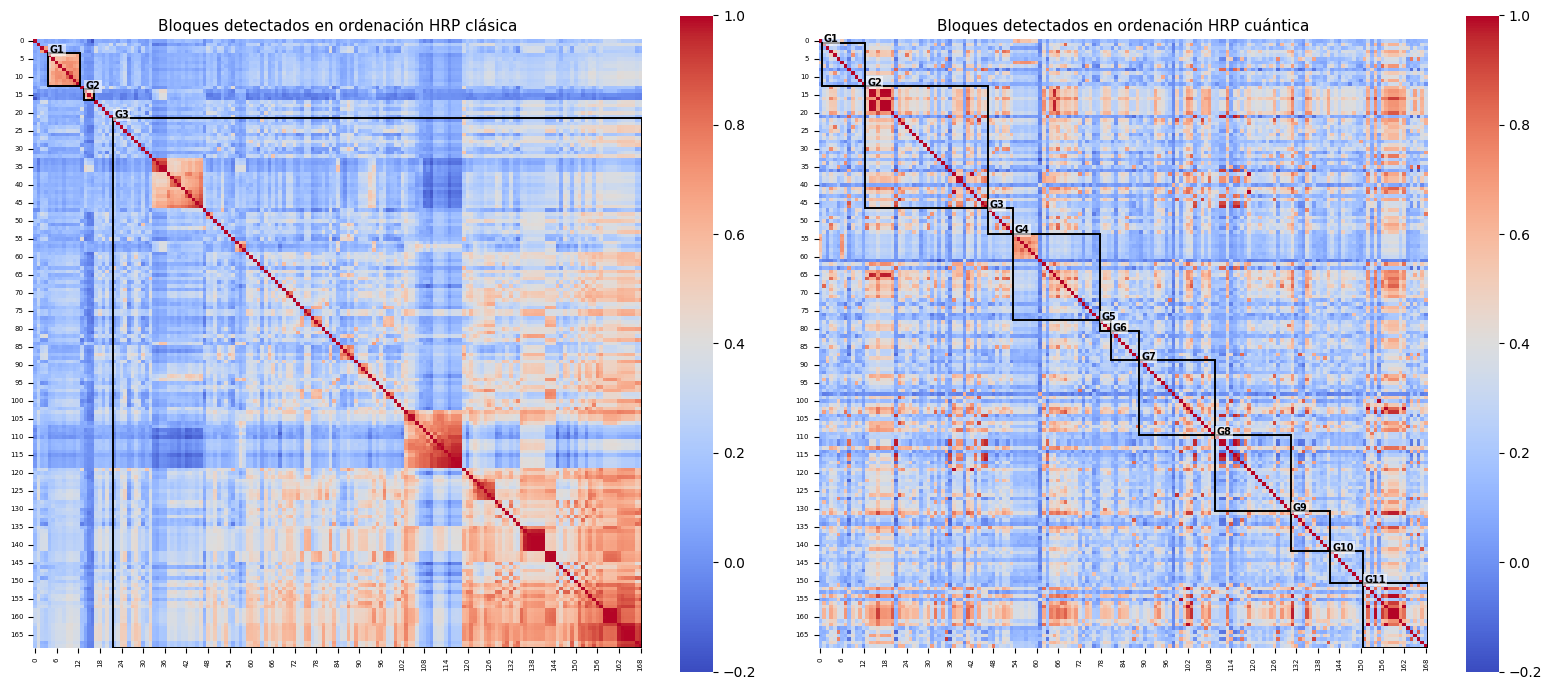

Figura con bloques guardada:
- /home/iker/TFG/latex/img/fig3-shuffled-blocks-marked-k12.png
- /home/iker/TFG/latex/img/fig3-shuffled-blocks-marked-k12.pdf


In [ ]:
# ── Visualización de bloques detectados (sin tocar celdas previas) ───────────
from matplotlib.patches import Rectangle

if "groups_classical" not in globals() or "groups_quantum" not in globals():
    raise RuntimeError("Primero ejecuta la celda anterior de agrupación para crear groups_classical/groups_quantum.")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Matrices ordenadas usadas para visualizar bloques
sns.heatmap(
    corr_classical_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=axes[0],
)
axes[0].set_title("Bloques detectados en ordenación HRP clásica", fontsize=11)

sns.heatmap(
    corr_quantum_shuf,
    cmap="coolwarm",
    vmin=-0.2,
    vmax=1.0,
    square=True,
    cbar=True,
    ax=axes[1],
)
axes[1].set_title("Bloques detectados en ordenación HRP cuántica", fontsize=11)

# Dibujar rectángulos de cada grupo contiguo detectado
def draw_group_rectangles(ax, groups_df, edge_color):
    for _, row in groups_df.iterrows():
        start = int(row["ordered_from"])
        end = int(row["ordered_to"])
        size = end - start + 1

        rect = Rectangle(
            (start, start),
            size,
            size,
            fill=False,
            edgecolor=edge_color,
            linewidth=1.4,
        )
        ax.add_patch(rect)

        # Etiqueta del grupo en la esquina del bloque
        ax.text(
            start + 0.5,
            start + 0.5,
            f"G{int(row['group_rank'])}",
            color=edge_color,
            fontsize=7,
            fontweight="bold",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.6, pad=1),
        )


draw_group_rectangles(axes[0], groups_classical, edge_color="black")
draw_group_rectangles(axes[1], groups_quantum, edge_color="black")

# Mantener etiquetas ligeras para que no se sature
for ax in axes:
    ax.tick_params(labelsize=5)

plt.tight_layout()
path_blocks_png = os.path.join(out_dir, f"fig3-shuffled-blocks-marked-k{groups_k}.png")
path_blocks_pdf = os.path.join(out_dir, f"fig3-shuffled-blocks-marked-k{groups_k}.pdf")
fig.savefig(path_blocks_png, dpi=300, bbox_inches="tight")
fig.savefig(path_blocks_pdf, bbox_inches="tight")
plt.show()

print("Figura con bloques guardada:")
print("-", path_blocks_png)
print("-", path_blocks_pdf)


Main groups (k=12): 11
Subgroups fine (k=36): 31
Microgroups fine (k=72): 45

Top subbloques finos (QHRP):


,sub_group,parent_main_group,n_assets,ordered_from,ordered_to,mean_corr_intra,mean_dist_intra,assets_preview
0,1,1,5,1,5,0.2690,0.0520,"META, PM, GS, BKR, NSC"
1,2,1,6,7,12,0.1896,0.0382,"NVDA, UNP, SHY, LCID, LLY, AVGO"
2,3,2,7,13,19,0.7989,0.0226,"BAC, IYR, XLRE, DIA, FREL, VNQ, SCHH"
3,4,2,4,20,23,0.3714,0.0351,"XLI, IEF, LIT, QCLN"
4,5,2,5,24,28,0.2915,0.0447,"CAT, CSX, SHOP, DIS, VZ"
5,6,2,4,29,32,0.2458,0.0556,"IBM, C, MSFT, LI"
6,7,2,7,33,39,0.2851,0.0264,"KRBN, AMD, XOM, TLT, VWO, VWOB, EMB"
7,8,2,7,40,46,0.3644,0.0396,"SOYB, IWM, EEM, TIP, PBW, VCIT, VCSH"
8,9,3,2,47,48,0.3577,0.0295,"XPEV, TSLA"
9,10,3,5,49,53,0.4224,0.0425,"WFC, MS, NFLX, SNOW, JPM"



Top microbloques finos (QHRP):


,micro_group,parent_main_group,n_assets,ordered_from,ordered_to,mean_corr_intra,mean_dist_intra,assets_preview
0,1,1,2,2,3,0.2541,0.0161,"PM, GS"
1,2,1,2,4,5,0.3273,0.0283,"BKR, NSC"
2,3,1,3,7,9,0.1358,0.0237,"NVDA, UNP, SHY"
3,4,1,3,10,12,0.1901,0.0360,"LCID, LLY, AVGO"
4,5,2,7,13,19,0.7989,0.0226,"BAC, IYR, XLRE, DIA, FREL, VNQ, SCHH"
5,6,2,4,20,23,0.3714,0.0351,"XLI, IEF, LIT, QCLN"
6,7,2,2,24,25,0.4740,0.0192,"CAT, CSX"
7,8,2,2,27,28,0.2062,0.0236,"DIS, VZ"
8,9,2,3,30,32,0.2535,0.0402,"C, MSFT, LI"
9,10,2,3,33,35,0.1398,0.0223,"KRBN, AMD, XOM"


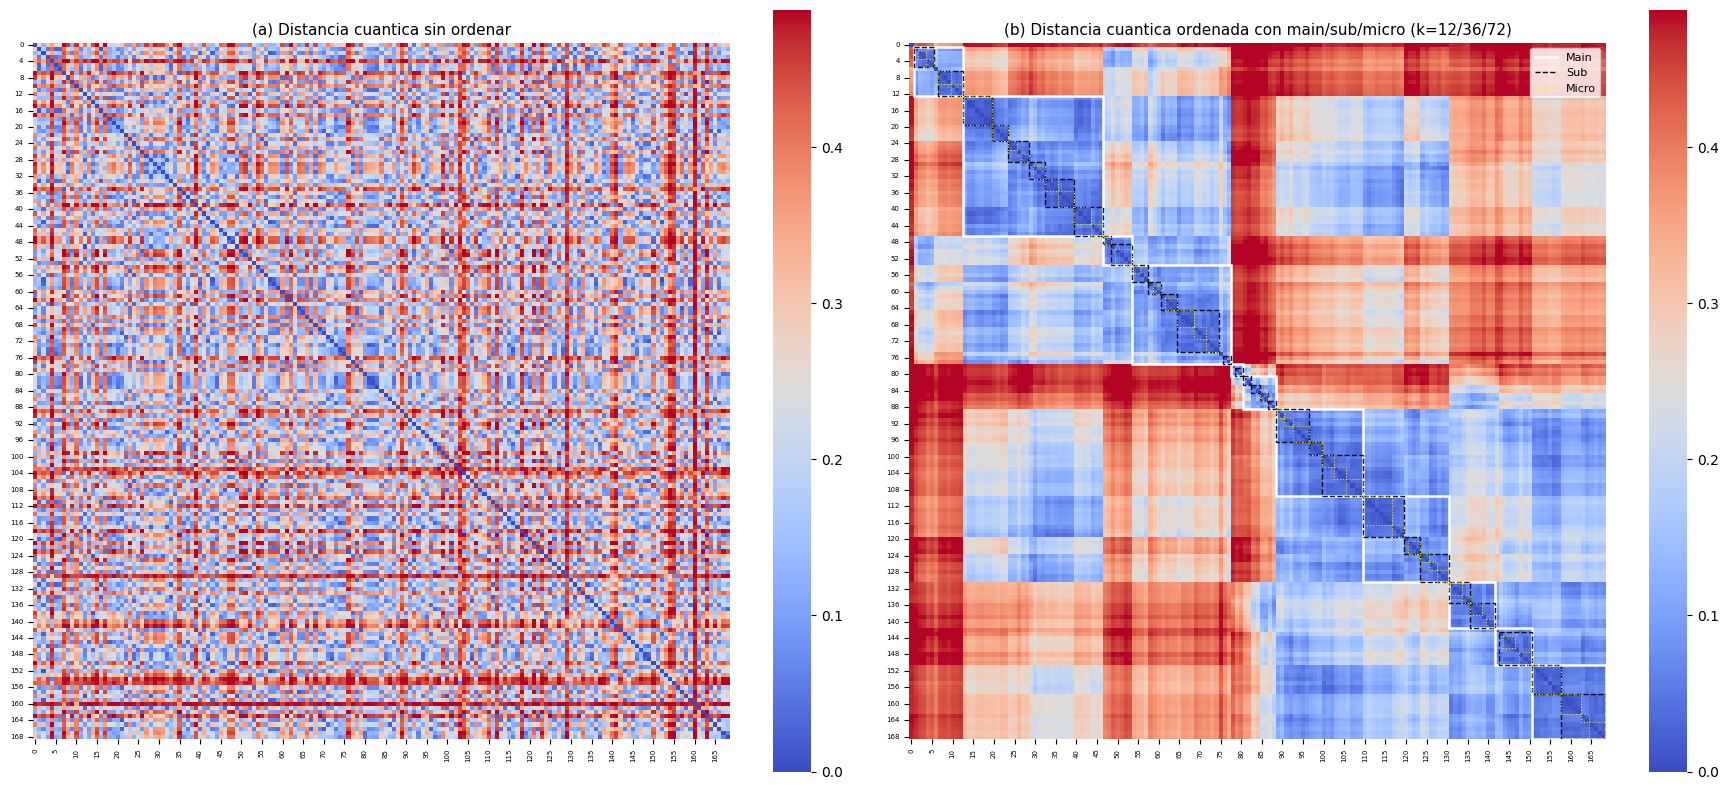


Salidas finas guardadas:
- /home/iker/TFG/latex/img/fig4-shuffled-quantum-subgroups-fine-k36.csv
- /home/iker/TFG/latex/img/fig4-shuffled-quantum-microgroups-fine-k72.csv
- /home/iker/TFG/latex/img/fig4-shuffled-hier-blocks-fine-k12-36-72.png
- /home/iker/TFG/latex/img/fig4-shuffled-hier-blocks-fine-k12-36-72.pdf


In [ ]:
# ── Ajuste fino adicional: subbloques y microbloques (Fig.4) ─────────────────
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import fcluster, linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# Parámetros de ajuste fino (puedes subirlos para ver aún más estructura)
k_sub_fine = 36
k_micro_fine = 72
min_sub_fine_size = 2
min_micro_fine_size = 2

# Dependencias funcionales mínimas
if "average_density_matrix" not in globals():
    repo_path = os.path.abspath("../../repos/RiskLabAI.py")
    if repo_path not in sys.path:
        sys.path.append(repo_path)
    from src.quantum_hrp import average_density_matrix

if "compute_distance_matrix_paper" not in globals():
    def _frobenius_distance_local(rho1, rho2, scale=1.5):
        diff = rho1 - rho2
        return scale * (0.5 * np.sqrt(np.trace(diff.conj().T @ diff)))

    def compute_distance_matrix_paper(rho_list):
        n_assets = len(rho_list)
        D = np.zeros((n_assets, n_assets))
        for i in range(n_assets):
            for j in range(i + 1, n_assets):
                d = _frobenius_distance_local(rho_list[i], rho_list[j])
                D[i, j] = d
                D[j, i] = d
        return D

if "quantum_ordering_ward" not in globals():
    def quantum_ordering_ward(D):
        Z = linkage(squareform(D), method="ward")
        return leaves_list(Z)

# Bootstrap de datos para ejecutar esta celda de forma aislada
if "returns" not in globals():
    returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
    returns = returns.apply(pd.to_numeric, errors="coerce")
    returns = returns.dropna(axis=0, how="any")
    returns = returns.dropna(axis=1, how="all")
    std = returns.std(axis=0)
    returns = returns.loc[:, std > 1e-8]

if "out_dir" not in globals():
    out_dir = os.path.abspath("../../latex/img")
    os.makedirs(out_dir, exist_ok=True)

if "N" not in globals():
    N = returns.shape[1]
if "R" not in globals():
    R = returns.values
if "T_total" not in globals():
    T_total = returns.shape[0]
if "alpha" not in globals():
    alpha = 2.0
if "window" not in globals():
    T_window_local = min(756, T_total)
    window = slice(-T_window_local, None)

if "features_old" not in globals():
    features_old = np.zeros((N, T_total, 6))
    for j in range(N):
        s = R[:, j]
        abs_s = np.abs(s)
        features_old[j, :, 0] = s
        features_old[j, :, 1] = s ** 2
        features_old[j, :, 2] = abs_s ** 1.5
        features_old[j, :, 3] = np.log1p(abs_s) * np.sign(s)
        features_old[j, :, 4] = np.tanh(s)
        features_old[j, :, 5] = np.sign(s) * np.sqrt(abs_s + 1e-6)

if "returns_shuf" not in globals():
    rng_local = np.random.default_rng(42)
    perm_local = rng_local.permutation(N)
    returns_shuf = returns.iloc[:, perm_local]

if "tickers_raw_shuf" not in globals():
    tickers_raw_shuf = returns_shuf.columns.tolist()

if "R_shuf" not in globals():
    R_shuf = returns_shuf.values
if "corr_shuf" not in globals():
    corr_shuf = np.corrcoef(R_shuf, rowvar=False)

if "features_old_shuf" not in globals():
    perm_infer = [returns.columns.get_loc(c) for c in returns_shuf.columns]
    features_old_shuf = features_old[perm_infer]

if "D_quantum_shuf" not in globals() or "order_quantum_shuf" not in globals():
    rho_list_shuf_local = []
    for i in range(features_old_shuf.shape[0]):
        rho_i = average_density_matrix(features_old_shuf[i][window], alpha)
        rho_list_shuf_local.append(rho_i)
    D_quantum_shuf = compute_distance_matrix_paper(rho_list_shuf_local) / 1.5  # scale=1.0
    order_quantum_shuf = quantum_ordering_ward(D_quantum_shuf)

if "link_quantum_shuf" not in globals():
    link_quantum_shuf = linkage(squareform(D_quantum_shuf), method="ward")
if "order_q" not in globals():
    order_q = np.asarray(order_quantum_shuf, dtype=int)

if "_contiguous_runs" not in globals():
    def _contiguous_runs(arr):
        runs = []
        n = len(arr)
        i = 0
        while i < n:
            j = i
            label = int(arr[i])
            while (j + 1) < n and int(arr[j + 1]) == label:
                j += 1
            runs.append((i, j, label))
            i = j + 1
        return runs

if "_mean_offdiag" not in globals():
    def _mean_offdiag(mat):
        if mat.shape[0] < 2:
            return np.nan
        tri = np.triu_indices_from(mat, 1)
        return float(np.nanmean(mat[tri]))


def build_contiguous_table(level_name, labels_raw, order_vec, min_size):
    labels_ordered = np.asarray(labels_raw, dtype=int)[order_vec]
    rows = []
    rank = 1

    for start, end, c_label in _contiguous_runs(labels_ordered):
        raw_idx = order_vec[start:end + 1]
        size = len(raw_idx)
        if size < min_size:
            continue

        tickers = [tickers_raw_shuf[i] for i in raw_idx]
        preview = ", ".join(tickers[:15])
        if size > 15:
            preview += f", ... (+{size - 15})"

        rows.append(
            {
                level_name: int(rank),
                "cluster_label": int(c_label),
                "n_assets": int(size),
                "ordered_from": int(start),
                "ordered_to": int(end),
                "mean_corr_intra": _mean_offdiag(corr_shuf[np.ix_(raw_idx, raw_idx)]),
                "mean_dist_intra": _mean_offdiag(D_quantum_shuf[np.ix_(raw_idx, raw_idx)]),
                "assets_preview": preview,
                "assets_all": " | ".join(tickers),
                "raw_indices": " | ".join(map(str, raw_idx.tolist())),
            }
        )
        rank += 1

    if not rows:
        return pd.DataFrame(
            columns=[
                level_name, "cluster_label", "n_assets", "ordered_from", "ordered_to",
                "mean_corr_intra", "mean_dist_intra", "assets_preview", "assets_all", "raw_indices"
            ]
        )

    return pd.DataFrame(rows).sort_values("ordered_from").reset_index(drop=True)


def assign_parent_main(df_child, df_main):
    if df_child.empty:
        df_child["parent_main_group"] = np.nan
        return df_child
    if df_main.empty:
        df_child["parent_main_group"] = np.nan
        return df_child

    parents = []
    for _, row in df_child.iterrows():
        s = int(row["ordered_from"])
        e = int(row["ordered_to"])
        m = df_main[(df_main["ordered_from"] <= s) & (df_main["ordered_to"] >= e)]
        parents.append(int(m.iloc[0]["main_group"]) if not m.empty else np.nan)

    out = df_child.copy()
    out.insert(1, "parent_main_group", parents)
    return out


# Bloques principales base
k_main_base = k_main if "k_main" in globals() else (groups_k if "groups_k" in globals() else 12)
labels_main_base = fcluster(link_quantum_shuf, t=k_main_base, criterion="maxclust")
groups_quantum_main_fine = build_contiguous_table("main_group", labels_main_base, order_q, min_size=3)

# Subbloques y microbloques más finos
labels_sub_fine = fcluster(link_quantum_shuf, t=k_sub_fine, criterion="maxclust")
labels_micro_fine = fcluster(link_quantum_shuf, t=k_micro_fine, criterion="maxclust")

groups_quantum_sub_fine = build_contiguous_table("sub_group", labels_sub_fine, order_q, min_size=min_sub_fine_size)
groups_quantum_micro_fine = build_contiguous_table("micro_group", labels_micro_fine, order_q, min_size=min_micro_fine_size)

groups_quantum_sub_fine = assign_parent_main(groups_quantum_sub_fine, groups_quantum_main_fine)
groups_quantum_micro_fine = assign_parent_main(groups_quantum_micro_fine, groups_quantum_main_fine)

print(f"Main groups (k={k_main_base}): {len(groups_quantum_main_fine)}")
print(f"Subgroups fine (k={k_sub_fine}): {len(groups_quantum_sub_fine)}")
print(f"Microgroups fine (k={k_micro_fine}): {len(groups_quantum_micro_fine)}")

print("\nTop subbloques finos (QHRP):")
display(groups_quantum_sub_fine[[
    "sub_group", "parent_main_group", "n_assets", "ordered_from", "ordered_to",
    "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].head(20).round(4))

print("\nTop microbloques finos (QHRP):")
display(groups_quantum_micro_fine[[
    "micro_group", "parent_main_group", "n_assets", "ordered_from", "ordered_to",
    "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].head(20).round(4))

# Exportar tablas finas
path_sub_fine_csv = os.path.join(out_dir, f"fig4-shuffled-quantum-subgroups-fine-k{k_sub_fine}.csv")
path_micro_fine_csv = os.path.join(out_dir, f"fig4-shuffled-quantum-microgroups-fine-k{k_micro_fine}.csv")
groups_quantum_sub_fine.to_csv(path_sub_fine_csv, index=False)
groups_quantum_micro_fine.to_csv(path_micro_fine_csv, index=False)

# Overlay Fig.4 con 3 niveles
D_ord_q_local = D_quantum_shuf[np.ix_(order_q, order_q)]
vmax_local = vmax_fig if "vmax_fig" in globals() else float(np.percentile(D_quantum_shuf[np.triu_indices_from(D_quantum_shuf, 1)], 97))
tickers_ord_local = [tickers_raw_shuf[i] for i in order_q]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (a) Sin ordenar
sns.heatmap(D_quantum_shuf, cmap="coolwarm", vmin=0, vmax=vmax_local, square=True, cbar=True, ax=axes[0])
axes[0].set_title("(a) Distancia cuantica sin ordenar", fontsize=11)
if "apply_sparse_ticker_ticks" in globals():
    apply_sparse_ticker_ticks(axes[0], tickers_raw_shuf, max_labels=28)
else:
    axes[0].tick_params(labelsize=5)

# (b) Ordenada con main/sub/micro bloques
sns.heatmap(D_ord_q_local, cmap="coolwarm", vmin=0, vmax=vmax_local, square=True, cbar=True, ax=axes[1])
axes[1].set_title(
    f"(b) Distancia cuantica ordenada con main/sub/micro (k={k_main_base}/{k_sub_fine}/{k_micro_fine})",
    fontsize=11,
)
if "apply_sparse_ticker_ticks" in globals():
    apply_sparse_ticker_ticks(axes[1], tickers_ord_local, max_labels=28)
else:
    axes[1].tick_params(labelsize=5)


def draw_rectangles(ax_, df_, edge_color, linestyle, linewidth, alpha=1.0):
    for _, r in df_.iterrows():
        s = int(r["ordered_from"])
        e = int(r["ordered_to"])
        size = e - s + 1
        ax_.add_patch(
            Rectangle(
                (s, s),
                size,
                size,
                fill=False,
                edgecolor=edge_color,
                linestyle=linestyle,
                linewidth=linewidth,
                alpha=alpha,
            )
        )


draw_rectangles(axes[1], groups_quantum_main_fine, edge_color="white", linestyle="-", linewidth=1.8, alpha=1.0)
draw_rectangles(axes[1], groups_quantum_sub_fine, edge_color="black", linestyle="--", linewidth=1.0, alpha=0.9)
draw_rectangles(axes[1], groups_quantum_micro_fine, edge_color="yellow", linestyle=":", linewidth=0.8, alpha=0.8)

legend_handles = [
    Line2D([0], [0], color="white", lw=1.8, linestyle="-", label="Main"),
    Line2D([0], [0], color="black", lw=1.0, linestyle="--", label="Sub"),
    Line2D([0], [0], color="yellow", lw=0.8, linestyle=":", label="Micro"),
]
axes[1].legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=8)

plt.tight_layout()
path_fig4_fine_png = os.path.join(out_dir, f"fig4-shuffled-hier-blocks-fine-k{k_main_base}-{k_sub_fine}-{k_micro_fine}.png")
path_fig4_fine_pdf = os.path.join(out_dir, f"fig4-shuffled-hier-blocks-fine-k{k_main_base}-{k_sub_fine}-{k_micro_fine}.pdf")
fig.savefig(path_fig4_fine_png, dpi=300, bbox_inches="tight")
fig.savefig(path_fig4_fine_pdf, bbox_inches="tight")
plt.show()

print("\nSalidas finas guardadas:")
print("-", path_sub_fine_csv)
print("-", path_micro_fine_csv)
print("-", path_fig4_fine_png)
print("-", path_fig4_fine_pdf)


## Experimento adicional: 5 desordenaciones distintas de activos

En esta sección repetimos el test de permutación con **cinco ordenaciones aleatorias diferentes** para analizar:

- Cómo cambian las imágenes sin ordenar.
- Si las matrices ordenadas (HRP clásico y HRP cuántico) mantienen estructura estable.
- Qué ordenación genera mayor "estructura de bloques" (relación visual-numérica).

In [ ]:
# ── 5 permutaciones distintas: métricas + matrices para visualizar ─────────
from scipy.cluster.hierarchy import linkage

# Si no existe features_old (porque no se ejecutó la celda previa), la construimos
if "features_old" not in globals():
    R_local = returns.values if "returns" in globals() else R
    N_local, T_local = R_local.shape[1], R_local.shape[0]
    features_old = np.zeros((N_local, T_local, 6))
    for j in range(N_local):
        for t in range(T_local):
            r = R_local[t, j]
            features_old[j, t, 0] = r
            features_old[j, t, 1] = r ** 2
            features_old[j, t, 2] = abs(r) ** 1.5
            features_old[j, t, 3] = np.log1p(abs(r)) * np.sign(r)
            features_old[j, t, 4] = np.tanh(r)
            features_old[j, t, 5] = np.sign(r) * np.sqrt(abs(r) + 1e-6)

# Referencias originales para comparar estabilidad
corr_ref = np.corrcoef(R, rowvar=False)
dist_ref_classical = np.sqrt((1 - corr_ref) / 2.0)
dist_ref_classical = 0.5 * (dist_ref_classical + dist_ref_classical.T)
np.fill_diagonal(dist_ref_classical, 0.0)
link_ref_classical = linkage(squareform(np.nan_to_num(dist_ref_classical)), method="single")
order_ref_classical = [int(x) for x in quasi_diagonal(link_ref_classical)]
corr_ref_classical = corr_ref[np.ix_(order_ref_classical, order_ref_classical)]

rho_ref = [average_density_matrix(features_old[i][window], alpha) for i in range(N)]
D_ref_quantum = compute_distance_matrix_paper(rho_ref) / 1.5  # scale=1.0
order_ref_quantum = quantum_ordering_ward(D_ref_quantum)
corr_ref_quantum = corr_ref[np.ix_(order_ref_quantum, order_ref_quantum)]

tri = np.triu_indices_from(corr_ref_classical, 1)
vec_ref_c = np.sort(corr_ref_classical[tri])
vec_ref_q = np.sort(corr_ref_quantum[tri])

def blockiness_corr(mat, band=8):
    n = mat.shape[0]
    ii, jj = np.indices((n, n))
    offdiag = ii != jj
    near = (np.abs(ii - jj) <= band) & offdiag
    far = (np.abs(ii - jj) > band)
    return np.mean(np.abs(mat[near])) - np.mean(np.abs(mat[far]))

seeds = [11, 22, 33, 44, 55]
perm_runs = []
rows = []

for k, seed in enumerate(seeds, 1):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)

    # Datos permutados
    corr_shuf = corr_ref[np.ix_(perm, perm)]
    features_old_shuf = features_old[perm]

    # HRP clásico sobre matriz permutada
    dist_c = np.sqrt((1 - corr_shuf) / 2.0)
    dist_c = 0.5 * (dist_c + dist_c.T)
    np.fill_diagonal(dist_c, 0.0)
    link_c = linkage(squareform(np.nan_to_num(dist_c)), method="single")
    order_c = [int(x) for x in quasi_diagonal(link_c)]
    corr_classical_shuf = corr_shuf[np.ix_(order_c, order_c)]

    # HRP cuántico sobre matriz permutada (features antiguas P=6, scale=1.0)
    rho_shuf = [average_density_matrix(features_old_shuf[i][window], alpha) for i in range(N)]
    D_shuf = compute_distance_matrix_paper(rho_shuf) / 1.5
    order_q = quantum_ordering_ward(D_shuf)
    D_shuf_ord = D_shuf[np.ix_(order_q, order_q)]
    corr_quantum_shuf = corr_shuf[np.ix_(order_q, order_q)]

    # Métricas de estabilidad estructural
    vec_c = np.sort(corr_classical_shuf[tri])
    vec_q = np.sort(corr_quantum_shuf[tri])
    sim_c = float(np.corrcoef(vec_ref_c, vec_c)[0, 1])
    sim_q = float(np.corrcoef(vec_ref_q, vec_q)[0, 1])

    b_u = blockiness_corr(corr_shuf)
    b_c = blockiness_corr(corr_classical_shuf)
    b_q = blockiness_corr(corr_quantum_shuf)

    rows.append({
        "perm_id": k,
        "seed": seed,
        "block_unordered": b_u,
        "block_classical": b_c,
        "block_quantum": b_q,
        "gain_classical": b_c - b_u,
        "gain_quantum": b_q - b_u,
        "sim_classical_vs_ref": sim_c,
        "sim_quantum_vs_ref": sim_q,
    })

    perm_runs.append({
        "perm_id": k,
        "seed": seed,
        "corr_unordered": corr_shuf,
        "corr_classical": corr_classical_shuf,
        "corr_quantum": corr_quantum_shuf,
        "D_quantum_unordered": D_shuf,
        "D_quantum_ordered": D_shuf_ord,
    })

perm_summary = pd.DataFrame(rows)

print("Resumen de 5 permutaciones (ganancia de estructura respecto a sin ordenar):")
display(
    perm_summary[[
        "perm_id", "seed", "gain_classical", "gain_quantum",
        "sim_classical_vs_ref", "sim_quantum_vs_ref"
    ]].round(4)
)

print("Media de ganancias:")
print(
    perm_summary[["gain_classical", "gain_quantum"]].mean().round(4).to_string()
)


Resumen de 5 permutaciones (ganancia de estructura respecto a sin ordenar):


,perm_id,seed,gain_classical,gain_quantum,sim_classical_vs_ref,sim_quantum_vs_ref
0,1,11,0.1402,0.0234,1.0,1.0
1,2,22,0.1479,0.0314,1.0,1.0
2,3,33,0.1421,0.0253,1.0,1.0
3,4,44,0.1448,0.0280,1.0,1.0
4,5,55,0.1472,0.0307,1.0,1.0


Media de ganancias:
gain_classical    0.1444
gain_quantum      0.0278


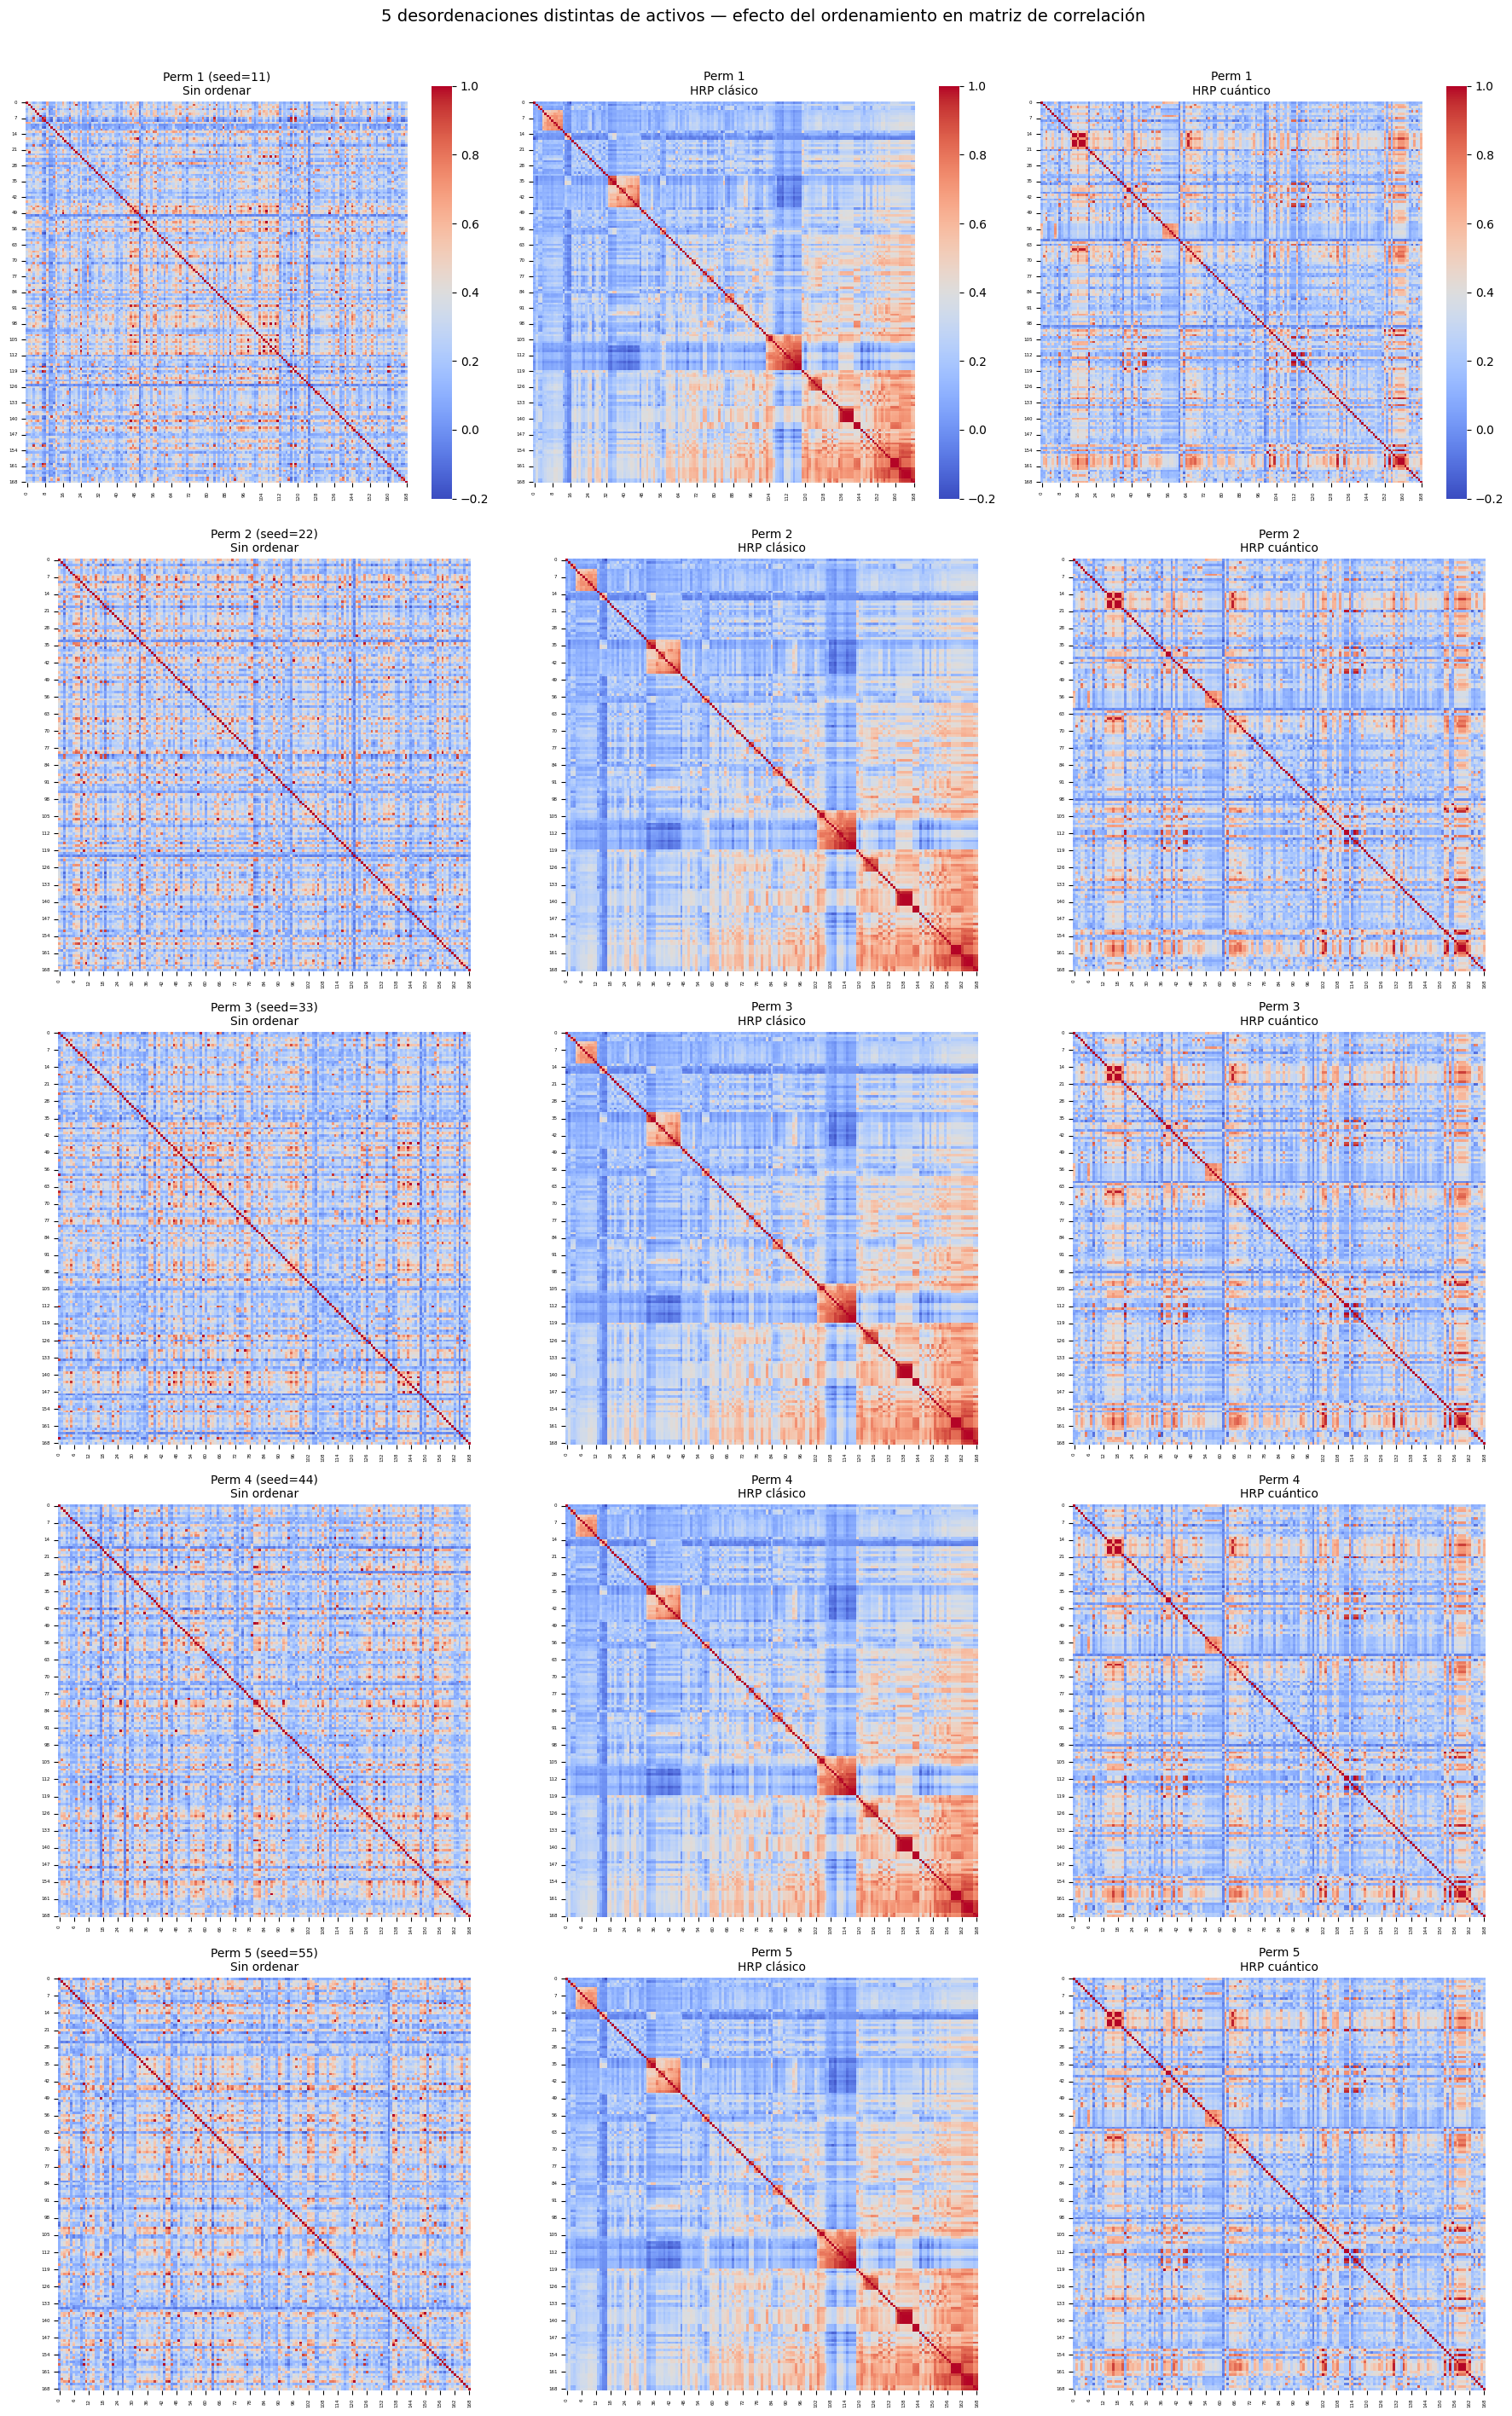

In [ ]:
# ── Visualización 1: correlaciones (sin ordenar vs clásico vs cuántico) en 5 permutaciones ──
fig, axes = plt.subplots(5, 3, figsize=(18, 28))

for r, run in enumerate(perm_runs):
    mats = [run["corr_unordered"], run["corr_classical"], run["corr_quantum"]]
    titles = [
        f"Perm {run['perm_id']} (seed={run['seed']})\nSin ordenar",
        f"Perm {run['perm_id']}\nHRP clásico",
        f"Perm {run['perm_id']}\nHRP cuántico",
    ]

    for c in range(3):
        sns.heatmap(
            mats[c], cmap="coolwarm", vmin=-0.2, vmax=1.0,
            square=True, cbar=(r == 0), ax=axes[r, c]
        )
        axes[r, c].set_title(titles[c], fontsize=10)
        axes[r, c].tick_params(labelsize=4)

plt.suptitle(
    "5 desordenaciones distintas de activos — efecto del ordenamiento en matriz de correlación",
    fontsize=14, y=1.01
)
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig3-five-permutations-corr.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig3-five-permutations-corr.pdf"), bbox_inches="tight")
plt.show()

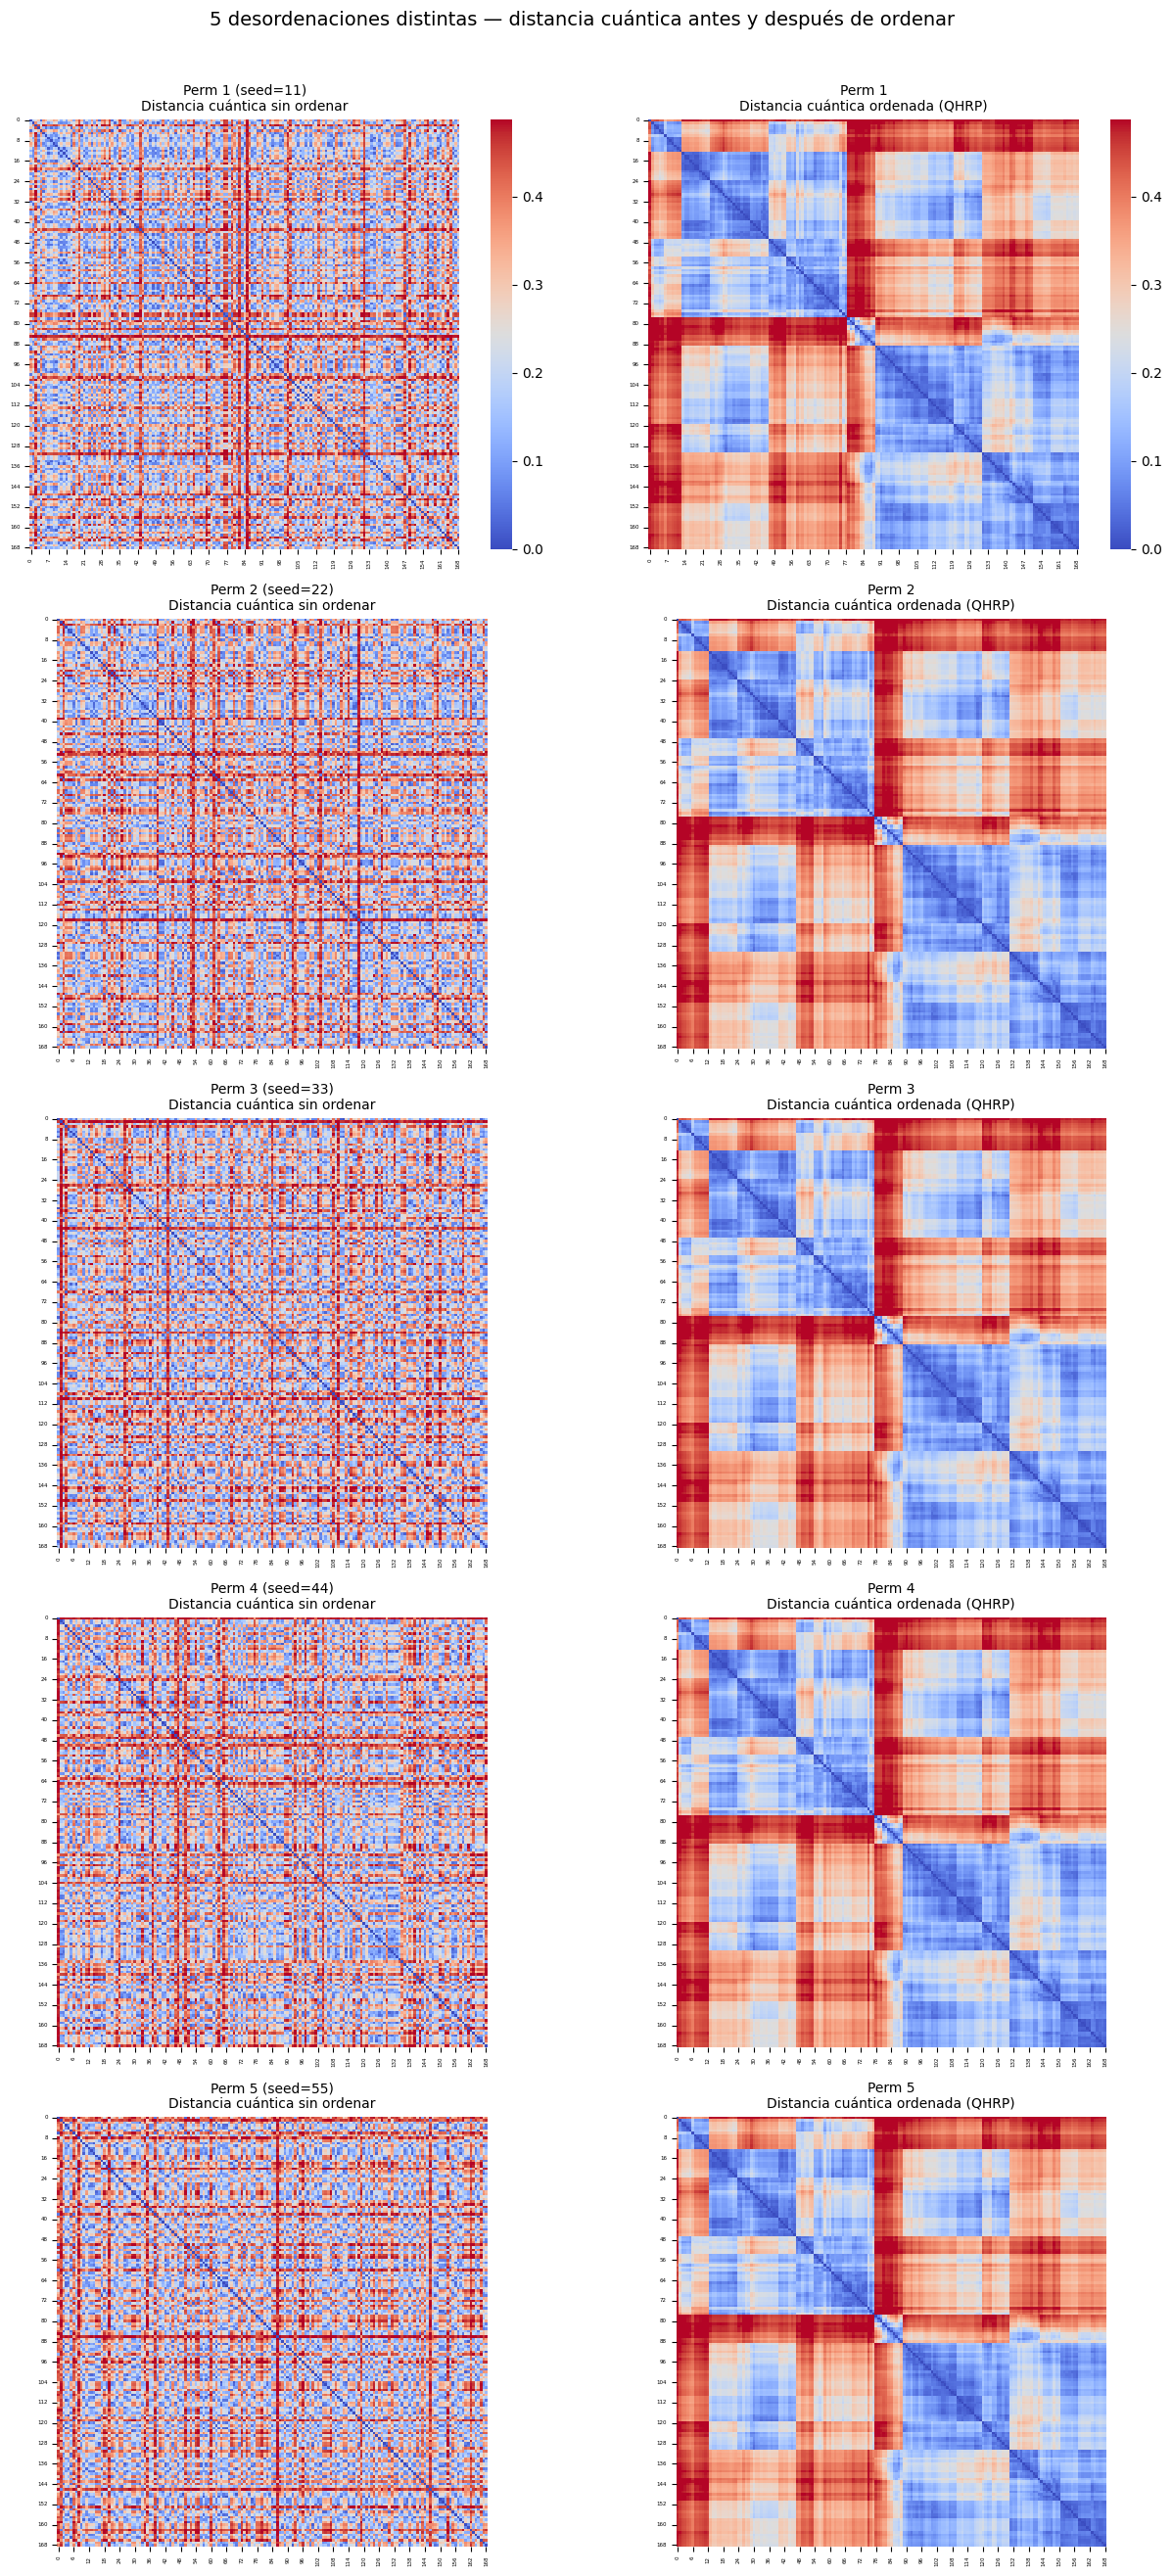

In [ ]:
# ── Visualización 2: distancia cuántica (sin ordenar vs ordenada) en 5 permutaciones ──
fig, axes = plt.subplots(5, 2, figsize=(13, 26))

for r, run in enumerate(perm_runs):
    D_u = run["D_quantum_unordered"]
    D_o = run["D_quantum_ordered"]

    # Escala común por permutación para comparación justa
    vmax_r = np.percentile(D_u[np.triu_indices_from(D_u, 1)], 97)

    sns.heatmap(D_u, cmap="coolwarm", vmin=0, vmax=vmax_r,
                square=True, cbar=(r == 0), ax=axes[r, 0])
    axes[r, 0].set_title(f"Perm {run['perm_id']} (seed={run['seed']})\nDistancia cuántica sin ordenar", fontsize=10)
    axes[r, 0].tick_params(labelsize=4)

    sns.heatmap(D_o, cmap="coolwarm", vmin=0, vmax=vmax_r,
                square=True, cbar=(r == 0), ax=axes[r, 1])
    axes[r, 1].set_title(f"Perm {run['perm_id']}\nDistancia cuántica ordenada (QHRP)", fontsize=10)
    axes[r, 1].tick_params(labelsize=4)

plt.suptitle(
    "5 desordenaciones distintas — distancia cuántica antes y después de ordenar",
    fontsize=14, y=1.01
)
plt.tight_layout()
fig.savefig(os.path.join(out_dir, "fig4-five-permutations-quantum-distance.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "fig4-five-permutations-quantum-distance.pdf"), bbox_inches="tight")
plt.show()

In [ ]:
# ── Ajuste fino para Figura 3 (1 arriba + 2 abajo) con tablas de grupos ─────
from scipy.cluster.hierarchy import fcluster, linkage, leaves_list
from scipy.spatial.distance import squareform
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# Parámetros de granularidad (ajusta si quieres más/menos detalle)
k_main_fig3 = 12
k_sub_fig3 = 28
k_micro_fig3 = 56
min_main_size_fig3 = 3
min_sub_size_fig3 = 2
min_micro_size_fig3 = 2
max_members_preview_fig3 = 18

# Bootstrap mínimo para ejecución aislada
if "returns" not in globals():
    returns = pd.read_csv("../../data/returns.csv", index_col=0, parse_dates=True)
    returns = returns.apply(pd.to_numeric, errors="coerce")
    returns = returns.dropna(axis=0, how="any")
    returns = returns.dropna(axis=1, how="all")
    std = returns.std(axis=0)
    returns = returns.loc[:, std > 1e-8]

if "R" not in globals():
    R = returns.values
if "N" not in globals():
    N = returns.shape[1]
if "T_total" not in globals():
    T_total = returns.shape[0]
if "alpha" not in globals():
    alpha = 2.0
if "window" not in globals():
    T_window_local = min(756, T_total)
    window = slice(-T_window_local, None)
if "out_dir" not in globals():
    out_dir = os.path.abspath("../../latex/img")
    os.makedirs(out_dir, exist_ok=True)

# Dependencias funcionales
if "average_density_matrix" not in globals():
    repo_path = os.path.abspath("../../repos/RiskLabAI.py")
    if repo_path not in sys.path:
        sys.path.append(repo_path)
    from src.quantum_hrp import average_density_matrix

if "compute_distance_matrix_paper" not in globals():
    def _frobenius_distance_local(rho1, rho2, scale=1.5):
        diff = rho1 - rho2
        return scale * (0.5 * np.sqrt(np.trace(diff.conj().T @ diff)))

    def compute_distance_matrix_paper(rho_list):
        n_assets = len(rho_list)
        D = np.zeros((n_assets, n_assets))
        for i in range(n_assets):
            for j in range(i + 1, n_assets):
                d = _frobenius_distance_local(rho_list[i], rho_list[j])
                D[i, j] = d
                D[j, i] = d
        return D

if "quantum_ordering_ward" not in globals():
    def quantum_ordering_ward(D):
        Z = linkage(squareform(D), method="ward")
        return leaves_list(Z)

if "quasi_diagonal" not in globals():
    def quasi_diagonal(linkage_matrix):
        linkage_matrix = linkage_matrix.astype(int)
        sorted_items = pd.Series([linkage_matrix[-1, 0], linkage_matrix[-1, 1]])
        num_items = linkage_matrix[-1, 3]
        while sorted_items.max() >= num_items:
            sorted_items.index = range(0, sorted_items.shape[0] * 2, 2)
            dataframe = sorted_items[sorted_items >= num_items]
            i = dataframe.index
            j = dataframe.values - num_items
            sorted_items[i] = linkage_matrix[j, 0]
            dataframe = pd.Series(linkage_matrix[j, 1], index=i + 1)
            sorted_items = sorted_items._append(dataframe)
            sorted_items = sorted_items.sort_index()
            sorted_items.index = range(sorted_items.shape[0])
        return sorted_items.tolist()

if "apply_sparse_ticker_ticks" not in globals():
    def apply_sparse_ticker_ticks(ax, tickers, max_labels=28):
        n = len(tickers)
        if n == 0:
            ax.set_xticks([])
            ax.set_yticks([])
            return
        step = max(1, int(np.ceil(n / max(1, int(max_labels)))))
        idx = np.arange(0, n, step)
        labels = [f"{i}:{tickers[i]}" for i in idx]
        ax.set_xticks(idx + 0.5)
        ax.set_yticks(idx + 0.5)
        ax.set_xticklabels(labels, rotation=90, fontsize=6)
        ax.set_yticklabels(labels, rotation=0, fontsize=6)

# Matriz de correlación base
if "corr" in globals() and corr.shape == (N, N):
    corr_base = corr
else:
    corr_base = np.corrcoef(R, rowvar=False)

tickers_base = returns.columns.tolist()

# Ordenación clásica + linkage clásico
if "dist_classical" in globals() and dist_classical.shape == (N, N):
    dist_classical_base = dist_classical
else:
    dist_classical_base = np.sqrt((1 - corr_base) / 2.0)
    dist_classical_base = 0.5 * (dist_classical_base + dist_classical_base.T)
    np.fill_diagonal(dist_classical_base, 0.0)
    dist_classical_base = np.nan_to_num(dist_classical_base)

if "order_classical" in globals() and len(order_classical) == N:
    order_classical_base = np.asarray(order_classical, dtype=int)
else:
    link_classical_base = linkage(squareform(np.nan_to_num(dist_classical_base)), method="single")
    order_classical_base = np.asarray([int(x) for x in quasi_diagonal(link_classical_base)], dtype=int)

link_classical_base = linkage(squareform(np.nan_to_num(dist_classical_base)), method="single")
corr_classical_base = corr_base[np.ix_(order_classical_base, order_classical_base)]

# Distancia/ordenación cuántica base
if "D_quantum" in globals() and np.asarray(D_quantum).shape == (N, N):
    D_quantum_base = np.asarray(D_quantum)
else:
    if "features_old" not in globals():
        features_old = np.zeros((N, T_total, 6))
        for j in range(N):
            s = R[:, j]
            abs_s = np.abs(s)
            features_old[j, :, 0] = s
            features_old[j, :, 1] = s ** 2
            features_old[j, :, 2] = abs_s ** 1.5
            features_old[j, :, 3] = np.log1p(abs_s) * np.sign(s)
            features_old[j, :, 4] = np.tanh(s)
            features_old[j, :, 5] = np.sign(s) * np.sqrt(abs_s + 1e-6)

    rho_list_fig3 = []
    for i in range(N):
        rho_i = average_density_matrix(features_old[i][window], alpha)
        rho_list_fig3.append(rho_i)
    D_quantum_base = compute_distance_matrix_paper(rho_list_fig3)

if "order_quantum" in globals() and len(order_quantum) == N:
    order_quantum_base = np.asarray(order_quantum, dtype=int)
else:
    order_quantum_base = np.asarray(quantum_ordering_ward(D_quantum_base), dtype=int)

link_quantum_base = linkage(squareform(np.nan_to_num(D_quantum_base)), method="ward")
corr_quantum_base = corr_base[np.ix_(order_quantum_base, order_quantum_base)]


def _contiguous_runs(arr):
    runs = []
    i = 0
    n = len(arr)
    while i < n:
        j = i
        label_i = int(arr[i])
        while (j + 1) < n and int(arr[j + 1]) == label_i:
            j += 1
        runs.append((i, j, label_i))
        i = j + 1
    return runs


def _mean_offdiag(mat):
    if mat.shape[0] < 2:
        return np.nan
    tri = np.triu_indices_from(mat, 1)
    return float(np.nanmean(mat[tri]))


def build_contiguous_group_table(level_col, labels_raw, order_vec, tickers_raw, corr_raw, dist_raw, min_size=3, max_members=15):
    labels_ordered = np.asarray(labels_raw, dtype=int)[order_vec]
    rows = []
    rank = 1

    for start, end, c_label in _contiguous_runs(labels_ordered):
        raw_idx = np.asarray(order_vec[start:end + 1], dtype=int)
        size = len(raw_idx)
        if size < min_size:
            continue

        tickers = [tickers_raw[k] for k in raw_idx]
        preview = ", ".join(tickers[:max_members])
        if size > max_members:
            preview += f", ... (+{size - max_members})"

        rows.append(
            {
                level_col: int(rank),
                "cluster_label": int(c_label),
                "n_assets": int(size),
                "ordered_from": int(start),
                "ordered_to": int(end),
                "mean_corr_intra": _mean_offdiag(corr_raw[np.ix_(raw_idx, raw_idx)]),
                "mean_dist_intra": _mean_offdiag(dist_raw[np.ix_(raw_idx, raw_idx)]),
                "assets_preview": preview,
                "assets_all": " | ".join(tickers),
                "raw_indices": " | ".join(map(str, raw_idx.tolist())),
            }
        )
        rank += 1

    if not rows:
        return pd.DataFrame(
            columns=[
                level_col,
                "cluster_label",
                "n_assets",
                "ordered_from",
                "ordered_to",
                "mean_corr_intra",
                "mean_dist_intra",
                "assets_preview",
                "assets_all",
                "raw_indices",
            ]
        )

    return pd.DataFrame(rows).sort_values("ordered_from").reset_index(drop=True)


def add_parent_main(df_child, df_main, child_parent_col="parent_main_group"):
    out = df_child.copy()
    if out.empty:
        out[child_parent_col] = np.nan
        return out
    if df_main.empty:
        out[child_parent_col] = np.nan
        return out

    parents = []
    for _, row in out.iterrows():
        s = int(row["ordered_from"])
        e = int(row["ordered_to"])
        m = df_main[(df_main["ordered_from"] <= s) & (df_main["ordered_to"] >= e)]
        parents.append(int(m.iloc[0]["main_group"]) if not m.empty else np.nan)

    out.insert(1, child_parent_col, parents)
    return out


# Labels jerárquicos: clásico y cuántico
labels_class_main = fcluster(link_classical_base, t=k_main_fig3, criterion="maxclust")
labels_class_sub = fcluster(link_classical_base, t=k_sub_fig3, criterion="maxclust")
labels_class_micro = fcluster(link_classical_base, t=k_micro_fig3, criterion="maxclust")

labels_quant_main = fcluster(link_quantum_base, t=k_main_fig3, criterion="maxclust")
labels_quant_sub = fcluster(link_quantum_base, t=k_sub_fig3, criterion="maxclust")
labels_quant_micro = fcluster(link_quantum_base, t=k_micro_fig3, criterion="maxclust")

# Tablas de grupos HRP clásico
groups_class_main_fig3 = build_contiguous_group_table(
    "main_group", labels_class_main, order_classical_base, tickers_base,
    corr_base, dist_classical_base, min_size=min_main_size_fig3, max_members=max_members_preview_fig3
)
groups_class_sub_fig3 = build_contiguous_group_table(
    "sub_group", labels_class_sub, order_classical_base, tickers_base,
    corr_base, dist_classical_base, min_size=min_sub_size_fig3, max_members=max_members_preview_fig3
)
groups_class_micro_fig3 = build_contiguous_group_table(
    "micro_group", labels_class_micro, order_classical_base, tickers_base,
    corr_base, dist_classical_base, min_size=min_micro_size_fig3, max_members=max_members_preview_fig3
)

groups_class_sub_fig3 = add_parent_main(groups_class_sub_fig3, groups_class_main_fig3)
groups_class_micro_fig3 = add_parent_main(groups_class_micro_fig3, groups_class_main_fig3)

# Tablas de grupos QHRP
groups_quant_main_fig3 = build_contiguous_group_table(
    "main_group", labels_quant_main, order_quantum_base, tickers_base,
    corr_base, D_quantum_base, min_size=min_main_size_fig3, max_members=max_members_preview_fig3
)
groups_quant_sub_fig3 = build_contiguous_group_table(
    "sub_group", labels_quant_sub, order_quantum_base, tickers_base,
    corr_base, D_quantum_base, min_size=min_sub_size_fig3, max_members=max_members_preview_fig3
)
groups_quant_micro_fig3 = build_contiguous_group_table(
    "micro_group", labels_quant_micro, order_quantum_base, tickers_base,
    corr_base, D_quantum_base, min_size=min_micro_size_fig3, max_members=max_members_preview_fig3
)

groups_quant_sub_fig3 = add_parent_main(groups_quant_sub_fig3, groups_quant_main_fig3)
groups_quant_micro_fig3 = add_parent_main(groups_quant_micro_fig3, groups_quant_main_fig3)

print(f"[HRP clásico] main/sub/micro: {len(groups_class_main_fig3)}/{len(groups_class_sub_fig3)}/{len(groups_class_micro_fig3)}")
print(f"[QHRP] main/sub/micro: {len(groups_quant_main_fig3)}/{len(groups_quant_sub_fig3)}/{len(groups_quant_micro_fig3)}")

print("\nTabla grupos HRP clásico (main):")
display(groups_class_main_fig3[[
    "main_group", "n_assets", "ordered_from", "ordered_to", "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].round(4))

print("\nTabla grupos HRP clásico (sub):")
display(groups_class_sub_fig3[[
    "sub_group", "parent_main_group", "n_assets", "ordered_from", "ordered_to", "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].round(4))

print("\nTabla grupos QHRP (main):")
display(groups_quant_main_fig3[[
    "main_group", "n_assets", "ordered_from", "ordered_to", "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].round(4))

print("\nTabla grupos QHRP (sub):")
display(groups_quant_sub_fig3[[
    "sub_group", "parent_main_group", "n_assets", "ordered_from", "ordered_to", "mean_corr_intra", "mean_dist_intra", "assets_preview"
]].round(4))

# Exportar CSVs de tablas
path_class_main_csv = os.path.join(out_dir, f"fig3-fine-classical-main-k{k_main_fig3}.csv")
path_class_sub_csv = os.path.join(out_dir, f"fig3-fine-classical-sub-k{k_sub_fig3}.csv")
path_class_micro_csv = os.path.join(out_dir, f"fig3-fine-classical-micro-k{k_micro_fig3}.csv")
path_quant_main_csv = os.path.join(out_dir, f"fig3-fine-quantum-main-k{k_main_fig3}.csv")
path_quant_sub_csv = os.path.join(out_dir, f"fig3-fine-quantum-sub-k{k_sub_fig3}.csv")
path_quant_micro_csv = os.path.join(out_dir, f"fig3-fine-quantum-micro-k{k_micro_fig3}.csv")

groups_class_main_fig3.to_csv(path_class_main_csv, index=False)
groups_class_sub_fig3.to_csv(path_class_sub_csv, index=False)
groups_class_micro_fig3.to_csv(path_class_micro_csv, index=False)
groups_quant_main_fig3.to_csv(path_quant_main_csv, index=False)
groups_quant_sub_fig3.to_csv(path_quant_sub_csv, index=False)
groups_quant_micro_fig3.to_csv(path_quant_micro_csv, index=False)

# Figura 3 en layout grande: 1 arriba + 2 abajo
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.0])

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

sns.heatmap(corr_base, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=ax0)
ax0.set_title("(a) Matriz de Correlación (Sin ordenar)", fontsize=12)
apply_sparse_ticker_ticks(ax0, tickers_base, max_labels=28)

sns.heatmap(corr_classical_base, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=ax1)
ax1.set_title("(b) Matriz de Correlación (Ordenación HRP Clásica)", fontsize=11)
apply_sparse_ticker_ticks(ax1, [tickers_base[i] for i in order_classical_base], max_labels=28)

sns.heatmap(corr_quantum_base, cmap="coolwarm", vmin=-0.2, vmax=1.0, square=True, cbar=True, ax=ax2)
ax2.set_title("(c) Matriz de Correlación (Ordenación HRP Cuántica)", fontsize=11)
apply_sparse_ticker_ticks(ax2, [tickers_base[i] for i in order_quantum_base], max_labels=28)


def draw_blocks(ax, df_main, df_sub, df_micro):
    for _, r in df_main.iterrows():
        s = int(r["ordered_from"])
        e = int(r["ordered_to"])
        size = e - s + 1
        ax.add_patch(Rectangle((s, s), size, size, fill=False, edgecolor="white", linewidth=1.8, linestyle="-"))
    for _, r in df_sub.iterrows():
        s = int(r["ordered_from"])
        e = int(r["ordered_to"])
        size = e - s + 1
        ax.add_patch(Rectangle((s, s), size, size, fill=False, edgecolor="black", linewidth=1.0, linestyle="--", alpha=0.9))
    for _, r in df_micro.iterrows():
        s = int(r["ordered_from"])
        e = int(r["ordered_to"])
        size = e - s + 1
        ax.add_patch(Rectangle((s, s), size, size, fill=False, edgecolor="yellow", linewidth=0.8, linestyle=":", alpha=0.8))


draw_blocks(ax1, groups_class_main_fig3, groups_class_sub_fig3, groups_class_micro_fig3)
draw_blocks(ax2, groups_quant_main_fig3, groups_quant_sub_fig3, groups_quant_micro_fig3)

legend_handles = [
    Line2D([0], [0], color="white", lw=1.8, linestyle="-", label="Main"),
    Line2D([0], [0], color="black", lw=1.0, linestyle="--", label="Sub"),
    Line2D([0], [0], color="yellow", lw=0.8, linestyle=":", label="Micro"),
]
ax1.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=8)
ax2.legend(handles=legend_handles, loc="upper right", frameon=True, fontsize=8)

plt.tight_layout()
path_fig3_fine_png = os.path.join(out_dir, f"fig3-fine-hier-blocks-k{k_main_fig3}-{k_sub_fig3}-{k_micro_fig3}.png")
path_fig3_fine_pdf = os.path.join(out_dir, f"fig3-fine-hier-blocks-k{k_main_fig3}-{k_sub_fig3}-{k_micro_fig3}.pdf")
fig.savefig(path_fig3_fine_png, dpi=300, bbox_inches="tight")
fig.savefig(path_fig3_fine_pdf, bbox_inches="tight")
plt.show()

print("\nCSVs guardados:")
print("-", path_class_main_csv)
print("-", path_class_sub_csv)
print("-", path_class_micro_csv)
print("-", path_quant_main_csv)
print("-", path_quant_sub_csv)
print("-", path_quant_micro_csv)
print("\nFigura guardada:")
print("-", path_fig3_fine_png)
print("-", path_fig3_fine_pdf)

NameError: name 'pd' is not defined